# Networks Analysis

In [ ]:
import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import os
from matplotlib.colors import Normalize, TwoSlopeNorm

In [ ]:
figure_formatting = {
    "figsize": (21, 8),
    "sharey": True,
    "area_alpha": 0.7,
    "grid_line_color": "red",
    "grid_line_width": 2,
    "grid_line_zorder": 10,
    "grid_line_zorder_secondary": 9,
    "legend_ncol": 3,
    "legend_loc": "upper center",
    "legend_bbox_to_anchor": (0.5, -0.12),
    "legend_frameon": False,
    "bottom_margin": 0.18,
    "date_format": "%H:%M",
    "ylabel": "Power [MW]",
}


def apply_standard_timeseries_format(ax, title, date, title_suffix=""):
    if title_suffix:
        ax.set_title(f"{title} Day ({date}) - {title_suffix}")
    else:
        ax.set_title(f"{title} Day ({date})")
    ax.set_ylabel(figure_formatting["ylabel"])
    ax.set_xlabel("Time")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter(figure_formatting["date_format"]))

### Choose the networks to analyse

In [ ]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_scenario2040-ext_"

scenario_names = { 
    "germany_base2_": "Base Case",
    "germany_scenario2040-fixed": "Scenario 2040 Fixed",
    "germany_scenario2040-TP": "Scenario 2040 TP",
    "germany_scenario2040-ext": "Scenario 2040 Extension",
}

def get_scenario_display_name(folder_name):
    # Normalize keys so trailing underscores in folder names do not break lookups.
    normalized = folder_name.rstrip("_")
    return scenario_names.get(folder_name, scenario_names.get(normalized, normalized.replace("_", " ").title()))


scenario_display_name = get_scenario_display_name(folder)

### Create folder and paths

In [ ]:
# Create analysis output directory and logging file
analysis_dir = f"{home}/pypsa-eur/analysis/{folder}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "summary.txt")

# Initialize/clear the log file with header
with open(log_file, "w") as _f:
    _f.write(f"Networks comparison summary\n")

def log_print(*args, sep=' ', end='\n', also_print=True):
    """Helper to print and append to the summary log"""
    s = sep.join(str(a) for a in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, 'a') as _f:
        _f.write(s)

def save_fig(fig, name, dpi=150):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(analysis_dir, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    log_print(f"Saved figure: {fname}")

### Set paths

In [ ]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

# Use globally defined scenario display names so all plots get readable titles.
n1.name = f"{scenario_display_name} - Windy"
n2.name = f"{scenario_display_name} - Not Windy"
n3.name = f"{scenario_display_name} - Wind Variability"

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks


In [ ]:
carrier_display_names = {
    "onwind": "Onshore wind",
    "offwind-ac": "Offshore wind (AC)",
    "offwind-float": "Offshore wind (floating)",
    "solar": "Solar PV",
    "solar-hsat": "Solar PV (high satellite)",
    "hydro": "Hydro",
    "ror": "Run-of-river",
    "lignite": "Lignite",
    "coal": "Coal",
    "oil": "Oil",
    "OCGT": "OCGT",
    "CCGT": "CCGT",
    "biomass": "Biomass",
    "waste": "Waste",
    "geothermal": "Geothermal",
    "load": "Unserved Load",
    "battery discharge": "Battery discharge",
}

def carrier_label(name):
    return carrier_display_names.get(name, name)

## Check

### Installed capacities 

In [ ]:
component_specs = [("generators", "p_nom_opt"), ("storage_units", "p_nom_opt"), ("links", "p_nom_opt")]

for network_name, network in networks.items():
    carrier_capacity = pd.Series(dtype=float)

    for component_name, capacity_column in component_specs:
        component = getattr(network, component_name, None)
        if component is None or component.empty or "carrier" not in component.columns or capacity_column not in component.columns:
            continue
        carrier_capacity = carrier_capacity.add(component.groupby("carrier")[capacity_column].sum(), fill_value=0)

    carrier_capacity = carrier_capacity.sort_values(ascending=False)
    print(f"\n{network.name} installed capacity by carrier [MW]")
    if carrier_capacity.empty:
        print("  No carrier capacity found.")
    else:
        print(carrier_capacity.to_string(float_format=lambda value: f"{value:.2f}"))


Scenario 2040 Extension - Windy installed capacity by carrier [MW]
carrier
load                       inf
solar                367000.00
onwind               209000.00
offwind-ac            66000.00
CCGT                  29000.00
PHS                    7361.72
OCGT                   6112.74
ror                    6000.00
waste                  3127.66
biomass                3000.00
hydro                   402.24
geothermal               26.90
battery discharger        0.05
battery charger           0.05
H2 Fuel Cell              0.00
H2 Electrolysis           0.00
lignite                   0.00
coal                      0.00
oil                       0.00
offwind-float             0.00
offwind-dc                0.00
solar-hsat                0.00

Scenario 2040 Extension - Not Windy installed capacity by carrier [MW]
carrier
load                       inf
solar                367000.00
onwind               209000.00
battery discharger   128818.00
battery charger      126215.34
offwind

### Line extension

In [ ]:
for network in networks.values():
    log_print(f"\n{network.name} line capacities:")
    if "s_nom_opt" in network.lines and not network.lines.s_nom.equals(network.lines.s_nom_opt):
        log_print("  Line extension detected: 's_nom_opt' differs from 's_nom'.")
    else:
        log_print("  No line extension detected")


Scenario 2040 Extension - Windy line capacities:
  Line extension detected: 's_nom_opt' differs from 's_nom'.

Scenario 2040 Extension - Not Windy line capacities:
  Line extension detected: 's_nom_opt' differs from 's_nom'.

Scenario 2040 Extension - Wind Variability line capacities:
  Line extension detected: 's_nom_opt' differs from 's_nom'.


### Coal price 

In [ ]:
carrier_name = "coal"

for network in networks.values():
    if hasattr(network, "generators"):
        g = network.generators
        if "carrier" in g.columns and "marginal_cost" in g.columns:
            mask = g["carrier"] == carrier_name
            if mask.any():
                original_costs = g.loc[mask, "marginal_cost"].copy()
                print(f"Marginal costs for '{carrier_name}' generators in {network.name} from {original_costs.iloc[0]:.2f}")
            else:
                print(f"No '{carrier_name}' generators found to modify costs.")

Marginal costs for 'coal' generators in Scenario 2040 Extension - Windy from 21.98
Marginal costs for 'coal' generators in Scenario 2040 Extension - Not Windy from 21.98
Marginal costs for 'coal' generators in Scenario 2040 Extension - Wind Variability from 21.98


### Components

In [ ]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            log_print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Scenario 2040 Extension - Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Scenario 2040 Extension - Not Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Scenario 2040 Extension - Wind Variability
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900


### Network 

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/network.png


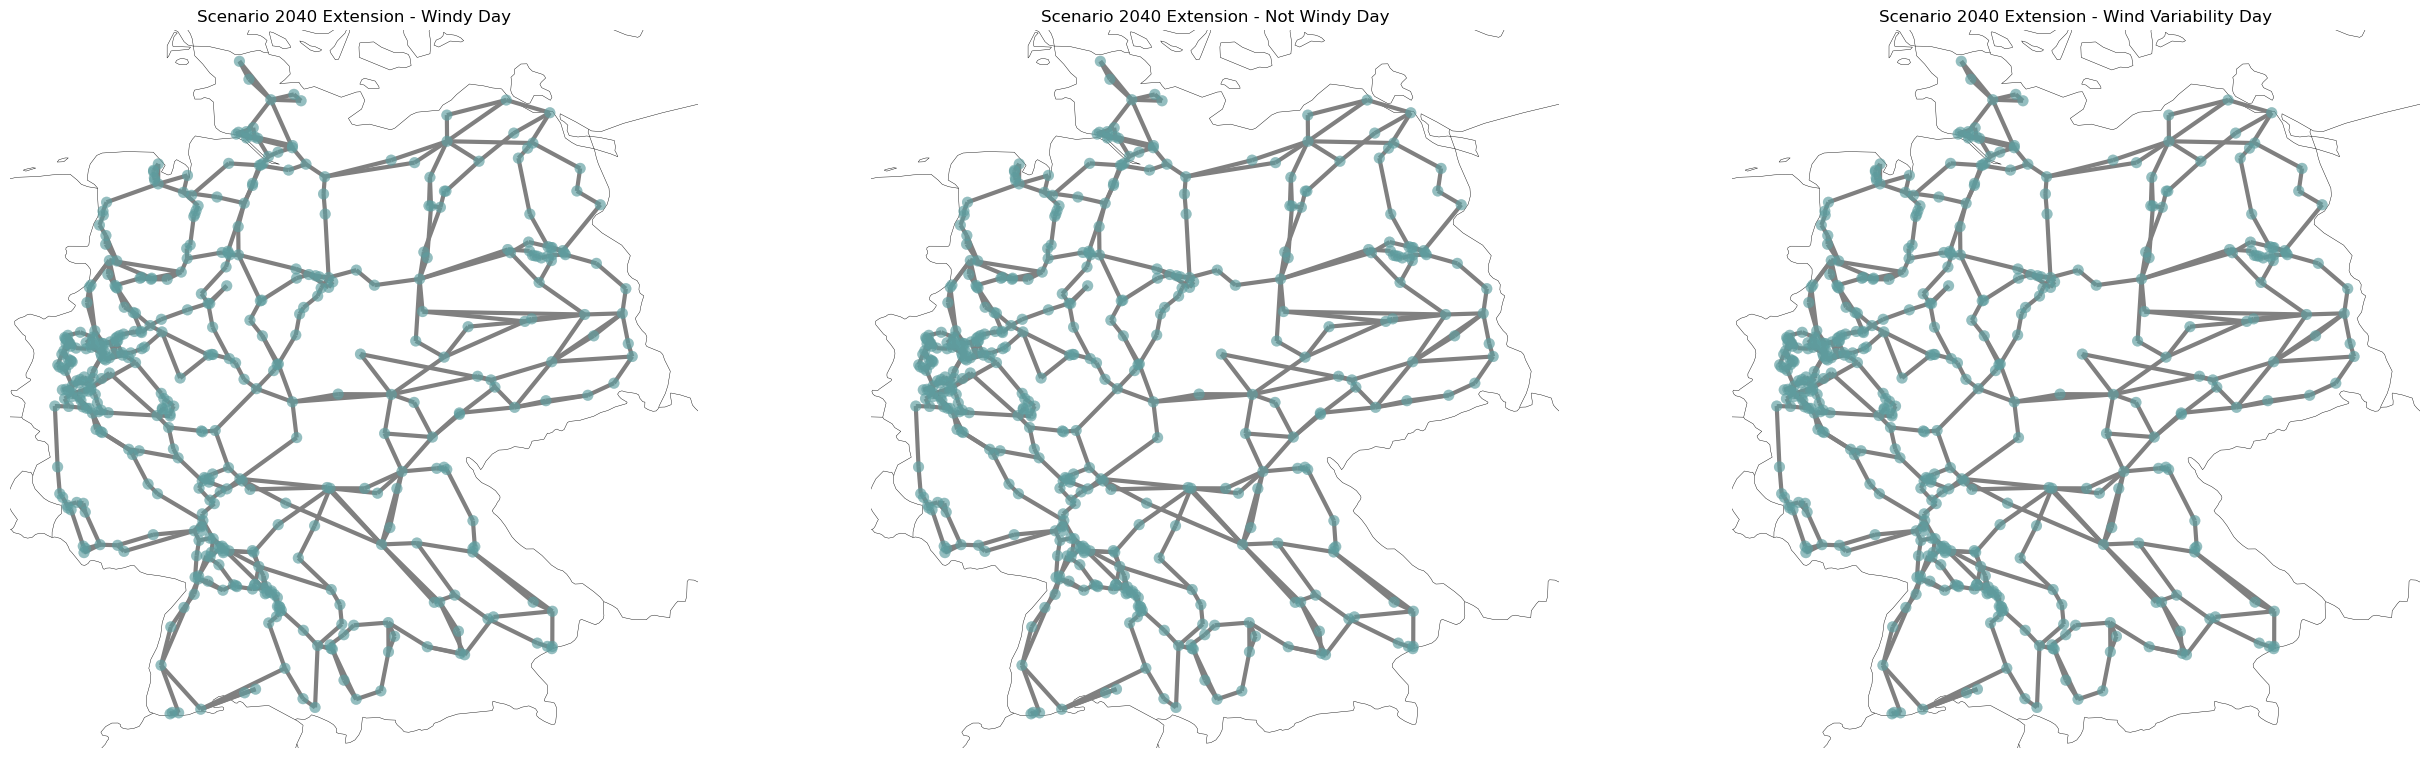

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network(n, ax, title):
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        link_alpha=0.5,
        line_width=3,
        link_width=3,
        link_color="darkgreen",
        line_color="gray",
    )

i = 0
for n in networks.values():
    plot_network(
        n,
        axes[i],
        n.name + " Day",
    )
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])

save_fig(fig, "network.png")

In [ ]:


map=n1.explore(
    line_width= n.lines.s_nom / 1000,
    link_width= n.links.p_nom / 1000,
    line_cmap="YlOrRd",
    bus_alpha=0.7,
    line_alpha=0.7,
    bus_color = "lightblue",
    line_color = "gray",
    link_color = "lightgreen",
)


path_to_dir = f"{analysis_dir}/network_interactive_map_{n.name}.html"
map.to_html(path_to_dir)

### Grid Congestion and Curtailment
Uses the average loading of each line and link, calculated as |p0| / s_nom for lines and |p0| / p_nom for links, with a YlOrRd color scale to highlight more heavily loaded branches.

/tmp/ipykernel_9500/3973531497.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 0, 0])


Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-fixed_/line_congestion.png


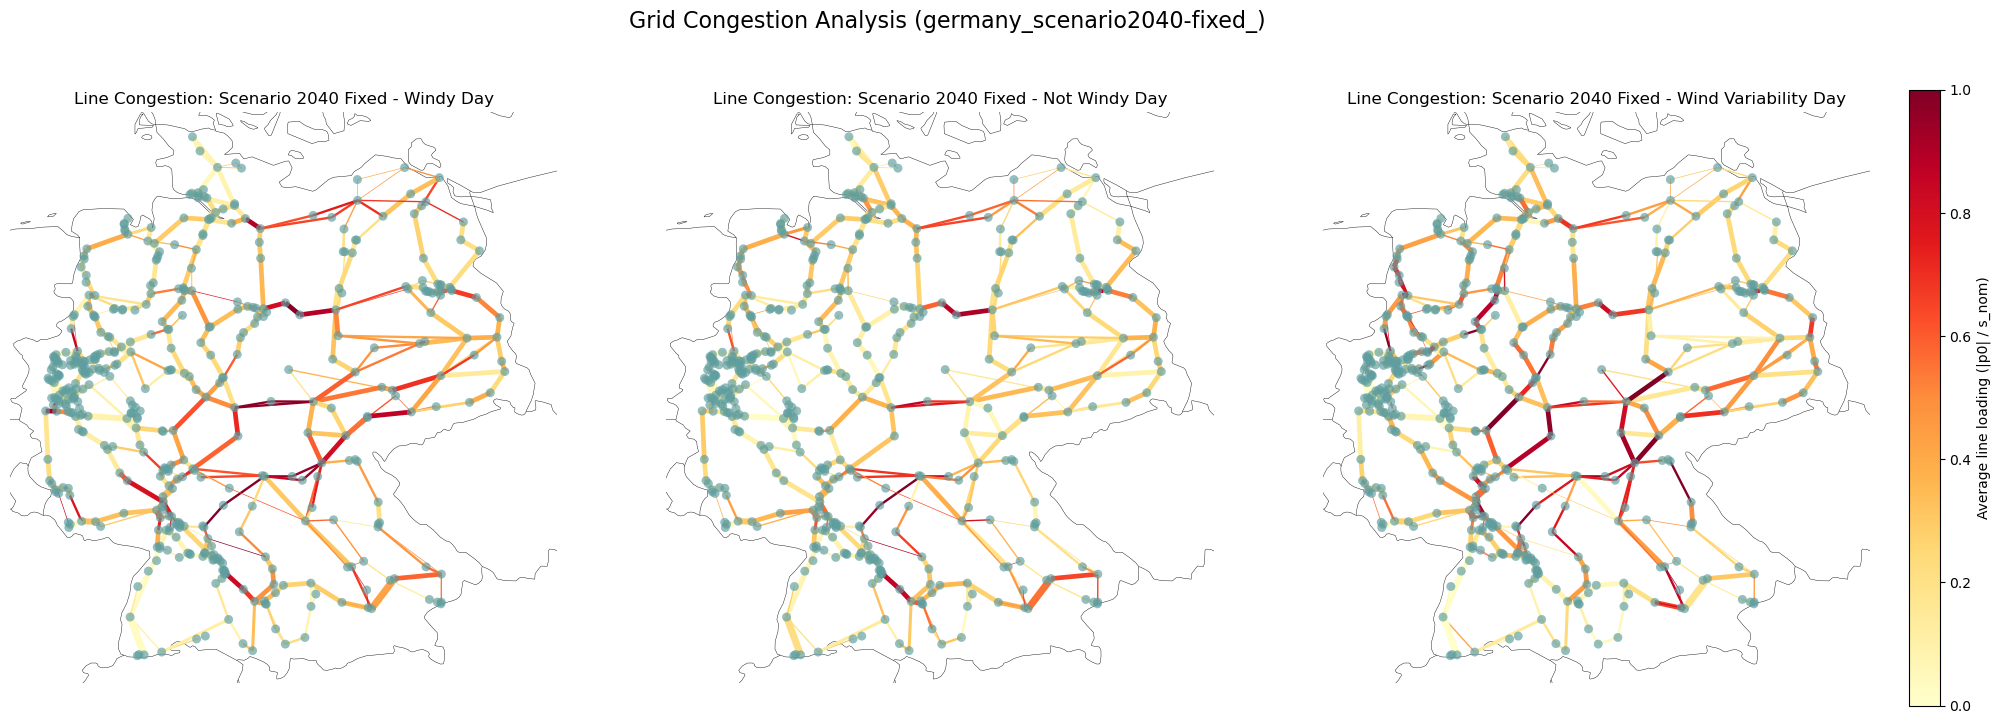

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(25, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Grid Congestion Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="YlOrRd",
        link_alpha=0.3,
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )
    return avg_loading_n, avg_loading_links

# Plot Average Loading Over All Snapshots for each network
line_loading_series = []
link_loading_series = []
i = 0
for n in networks.values():
    avg_loading_n, avg_loading_links = plot_network_congestion(
        n,
        axes[i],
        "Line Congestion: " + n.name + " Day",
    )
    line_loading_series.append(avg_loading_n)
    link_loading_series.append(avg_loading_links)
    i += 1

fig.tight_layout(rect=[0, 0, 0, 0])

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Add a legend-like colorbar for line loading.
line_max = max(1.0, max(series.max() for series in line_loading_series if not series.empty))
line_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=line_max), cmap=plt.get_cmap("YlOrRd"))
line_mappable.set_array([])
cbar_line = fig.colorbar(line_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
cbar_line.set_label("Average line loading (|p0| / s_nom)")

# Add a second colorbar for link loading.
#link_max = max(1.0, max(series.max() for series in link_loading_series if not series.empty))
#link_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=link_max), cmap=plt.get_cmap("YlOrRd"))
#link_mappable.set_array([])
#cbar_link = fig.colorbar(link_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.12)
#bar_link.set_label("Average link loading (|p0| / p_nom)")

save_fig(fig, "line_congestion.png")

/tmp/ipykernel_9500/984518443.py:59: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 0, 0])


Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-fixed_/line_congestion.png


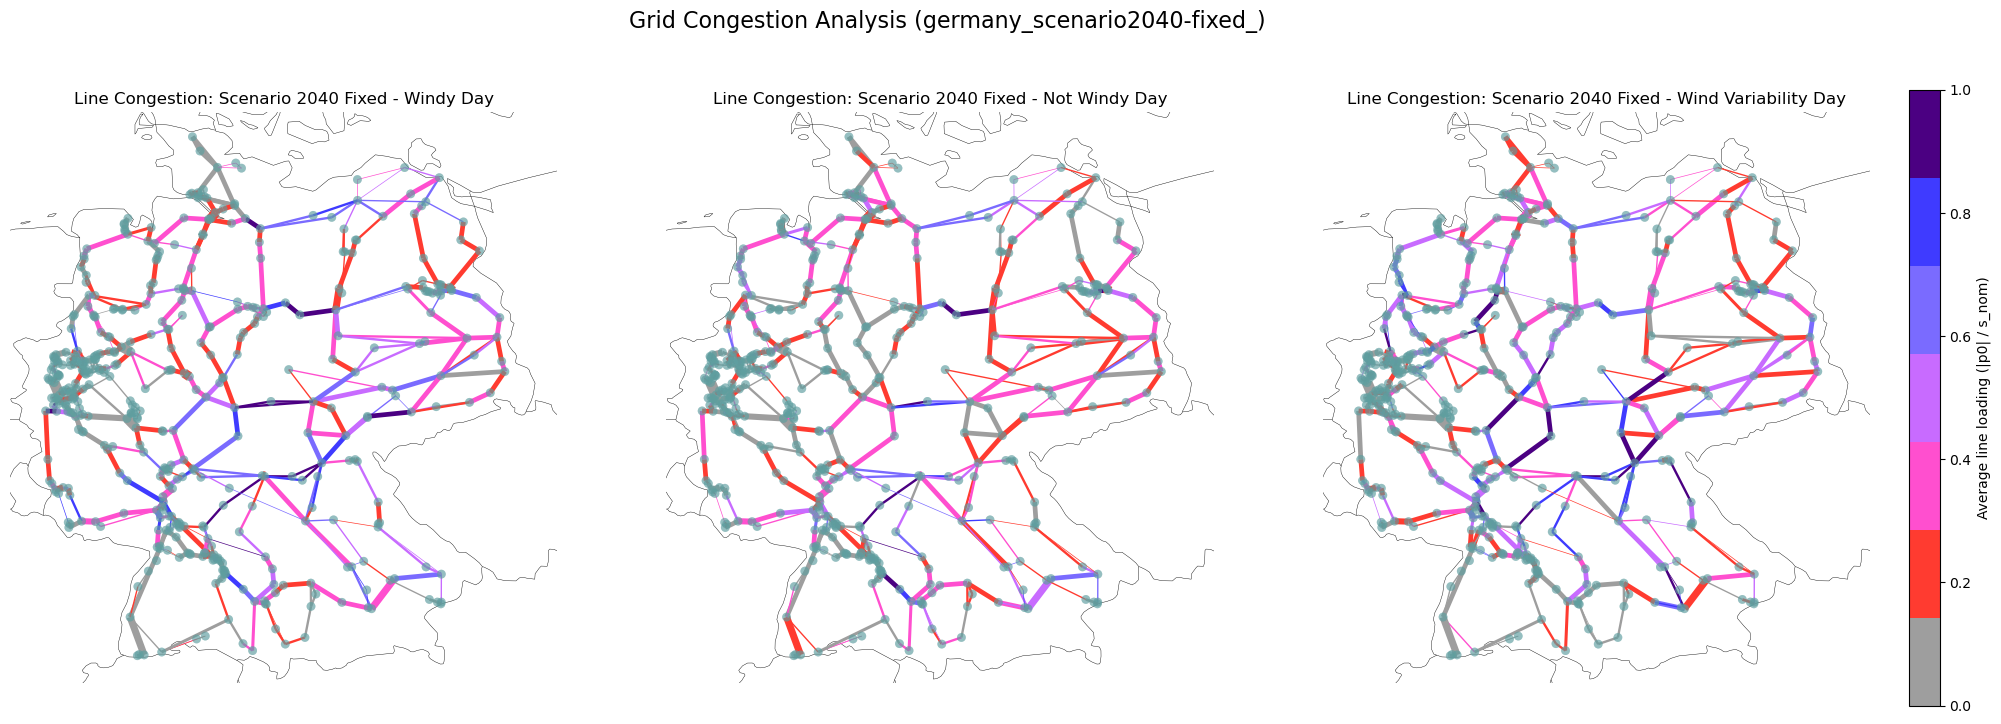

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(25, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Grid Congestion Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        line_colors=avg_loading_n,
        link_colors=avg_loading_links,
        line_cmap=cmap_congestion,
        link_cmap=cmap_congestion,
        link_alpha=0.3,
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )
    return avg_loading_n, avg_loading_links

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs

# --- Custom discrete colormap like your reference plot ---
colors = [
    "#9E9E9E",  # 0–100%
    "#FF3B30",  # 100–110%
    "#FF4FCF",  # 110–120%
    "#C86BFF",  # 120–130%
    "#7A6BFF",  # 130–140%
    "#3F3BFF",  # 140–150%
    "#4B0082",  # >150%
]

cmap_congestion = ListedColormap(colors, name="grid_congestion")

# Plot Average Loading Over All Snapshots for each network
line_loading_series = []
link_loading_series = []
i = 0
for n in networks.values():
    avg_loading_n, avg_loading_links = plot_network_congestion(
        n,
        axes[i],
        "Line Congestion: " + n.name + " Day",
    )
    line_loading_series.append(avg_loading_n)
    link_loading_series.append(avg_loading_links)
    i += 1

fig.tight_layout(rect=[0, 0, 0, 0])

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Add a legend-like colorbar for line loading.
line_max = max(1.0, max(series.max() for series in line_loading_series if not series.empty))
line_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=line_max), cmap=cmap_congestion)
line_mappable.set_array([])
cbar_line = fig.colorbar(line_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
cbar_line.set_label("Average line loading (|p0| / s_nom)")

# Add a second colorbar for link loading.
#link_max = max(1.0, max(series.max() for series in link_loading_series if not series.empty))
#link_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=link_max), cmap=plt.get_cmap("YlOrRd"))
#link_mappable.set_array([])
#cbar_link = fig.colorbar(link_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.12)
#bar_link.set_label("Average link loading (|p0| / p_nom)")

save_fig(fig, "line_congestion.png")

### Most extended lines
Shows line extension in percent, calculated as (s_nom_opt / s_nom - 1) * 100. The map colors lines and links from 0 percent extension to 100 percent when capacity doubles, with values clipped at zero for no extension.

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-fixed_/line_link_extension.png


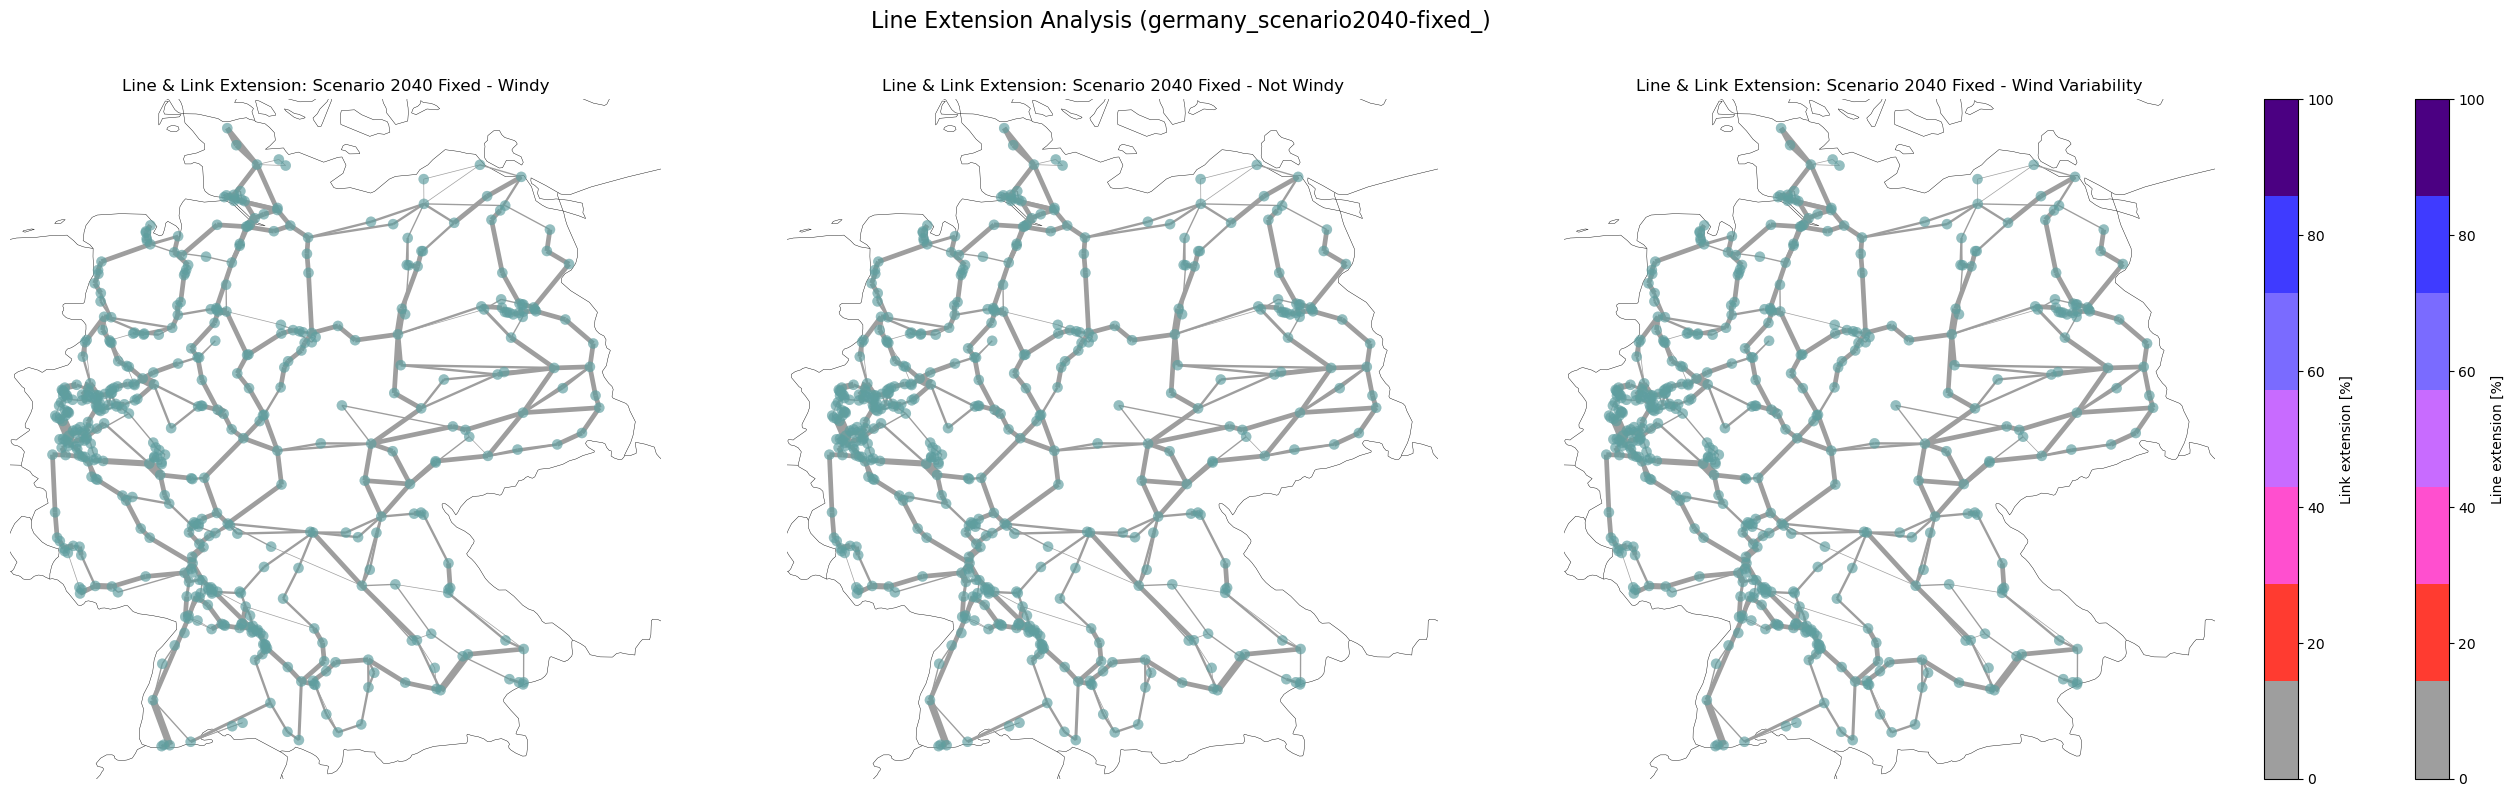

In [ ]:
# --- Line Extension Visualization (new) ---
# This cell plots line extension in percent, where 0% means no extension and 100% means doubling capacity.
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Line Extension Analysis ({folder})", fontsize=16)

# Helper to plot per-network static extension metric
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


# --- Custom discrete colormap like your reference plot ---
colors = [
    "#9E9E9E",  # 0–100%
    "#FF3B30",  # 100–110%
    "#FF4FCF",  # 110–120%
    "#C86BFF",  # 120–130%
    "#7A6BFF",  # 130–140%
    "#3F3BFF",  # 140–150%
    "#4B0082",  # >150%
]

cmap_congestion = ListedColormap(colors, name="grid_congestion")


def plot_line_link_extension(n, ax, title):

    # Convert extension to percent: 0% = s_nom_opt == s_nom, 100% = s_nom_opt == 2 * s_nom.
    if "s_nom_opt" in n.lines.columns and not n.lines.empty:
        line_ext = ((n.lines.s_nom_opt / n.lines.s_nom) - 1.0) * 100.0
        line_ext = line_ext.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    else:
        line_ext = pd.Series(0.0, index=n.lines.index)

    # Link extension: p_nom_opt / p_nom, converted to percent using the same convention.
    if hasattr(n, "links") and not n.links.empty and "p_nom_opt" in n.links.columns:
        link_ext = ((n.links.p_nom_opt / n.links.p_nom) - 1.0) * 100.0
        link_ext = link_ext.replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    elif hasattr(n, "links") and not n.links.empty:
        link_ext = pd.Series(0.0, index=n.links.index)
    else:
        link_ext = pd.Series(dtype=float)

    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.005,
        bus_alpha=0.3,
        line_colors=line_ext,
        line_cmap=cmap_congestion,
        link_colors=link_ext if not link_ext.empty else None,
        link_cmap=cmap_congestion,
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000 if not n.links.empty else 0,
    )
    return line_ext, link_ext

# Collect all series to build shared colorbars
line_extension_series = []
link_extension_series = []
for ax, n in zip(axes, networks.values()):
    title = "Line & Link Extension: " + n.name
    le, lx = plot_line_link_extension(n, ax, title)
    line_extension_series.append(le)
    link_extension_series.append(lx)

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Shared colorbar for lines
all_line_maxs = [s.max() for s in line_extension_series if not s.empty]
line_vmax = max(100.0, max(all_line_maxs)) if all_line_maxs else 100.0
line_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=line_vmax), cmap=cmap_congestion)
line_mappable.set_array([])
cbar_line = fig.colorbar(line_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.04)
cbar_line.set_label("Line extension [%]")

# Shared colorbar for links (only if links exist)
link_maxs = [s.max() for s in link_extension_series if not s.empty]
if link_maxs:
    link_vmax = max(100.0, max(link_maxs))
    link_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=link_vmax), cmap=cmap_congestion)
    link_mappable.set_array([])
    cbar_link = fig.colorbar(link_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
    cbar_link.set_label("Link extension [%]")

save_fig(fig, "line_link_extension.png")

### Marginal Prices
Bus prices are shown on a binned RdYlGn_r scale using the snapshot with the highest system-wide marginal price. Bus sizes come from load at that snapshot, and the shared colorbar uses discrete price ranges.

Plotting 'Scenario 2040 Extension - Windy' network at time 2025-10-26 16:00:00 with peak marginal price 33.90 €/MWh
Minimum marginal price across all buses at peak time: -0.00 €/MWh

Scenario 2040 Extension - Windy Marginal Price Statistics:
count    1350.000000
mean        7.675067
std         7.869569
min        -0.001468
25%         0.052957
50%         6.012397
75%        13.342156
max        33.899100
Peak marginal price range: -0.00 to 33.90 €/MWh

Plotting 'Scenario 2040 Extension - Not Windy' network at time 2025-04-08 23:00:00 with peak marginal price 37.91 €/MWh
Minimum marginal price across all buses at peak time: 28.49 €/MWh

Scenario 2040 Extension - Not Windy Marginal Price Statistics:
count    1350.000000
mean       34.264329
std         2.361781
min        28.489825
25%        32.823970
50%        34.872385
75%        35.844805
max        37.907672
Peak marginal price range: 28.49 to 37.91 €/MWh

Plotting 'Scenario 2040 Extension - Wind Variability' network at time 2025

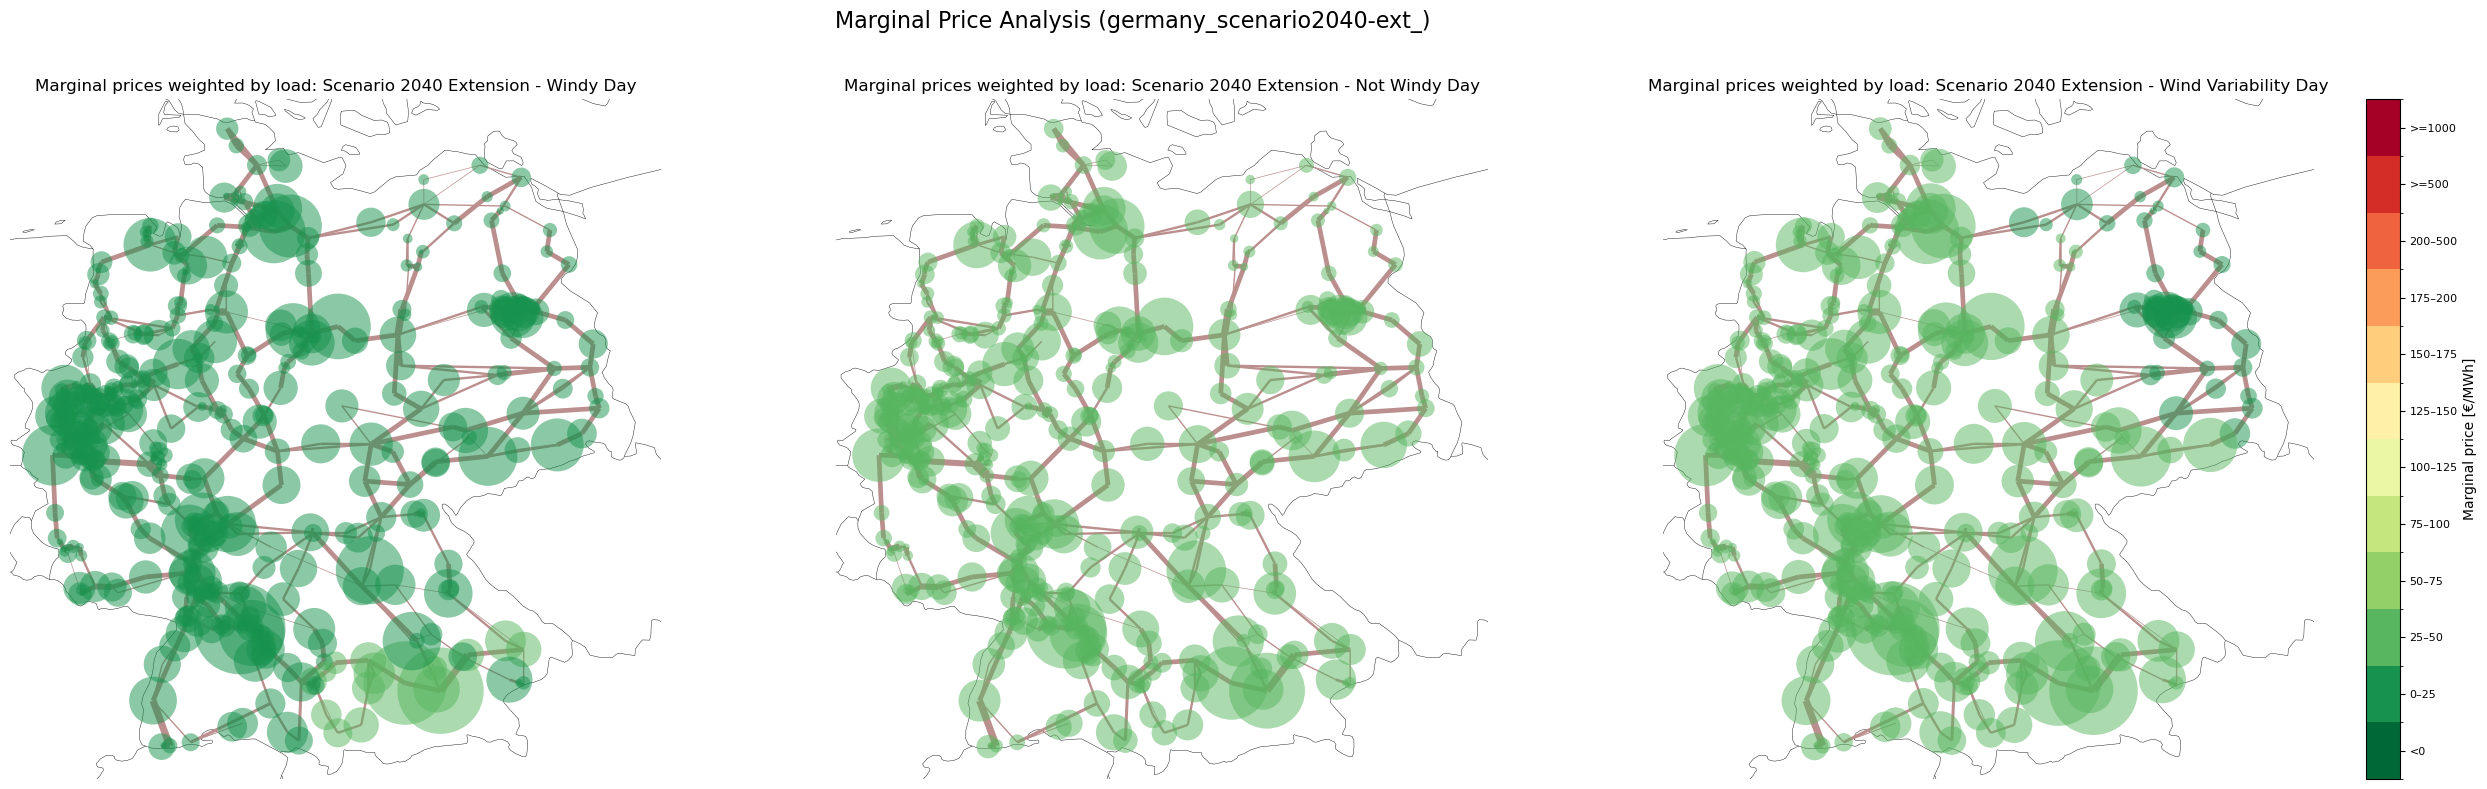

In [ ]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Marginal Price Analysis ({folder})", fontsize=16)

# --- Define the normalization for the color map ---
NORMAL_PRICE = 93.15
HIGH_PRICE_THRESHOLD = 10000.01
GLOBAL_MIN = -32.34203267754546

vmin = GLOBAL_MIN
vmax = HIGH_PRICE_THRESHOLD

# Adjust vmin and vmax to ensure vcenter is not at the boundary
if vmin >= NORMAL_PRICE:
    vmin = NORMAL_PRICE - 1
if vmax <= NORMAL_PRICE:
    vmax = NORMAL_PRICE + 1

from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm

# Discrete bins with denser resolution in the green area below 200 €/MWh
bins = [vmin, 0, 25, 50, 75, 100, 125, 150, 175, 200, 500, 1000, vmax]
bins = sorted(set(b for b in bins if vmin <= b <= vmax))
if len(bins) < 2:
    bins = [vmin, vmax]

marginal_price_norm = BoundaryNorm(bins, ncolors=plt.get_cmap("RdYlGn_r").N, clip=False)

# Use the same colormap, but the BoundaryNorm makes it appear in bins
cmap = plt.get_cmap('RdYlGn_r').copy()


# --- Helper Function to Plot Network with Average Loading ---
def plot_marginal_prices(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    avg_loading_links = (n.links_t.p0.abs() / n.links.p_nom).mean()
    
    # Calculate load at each bus by summing all loads attached to the same bus.
    bus_load = (
        n.loads_t.p_set.T.groupby(n.loads.bus).sum().T
        .reindex(columns=n.buses.index, fill_value=0.0)
    )
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    bus_load_at_peak = bus_load.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=bus_load_at_peak / 6000,
        bus_colors=peak_prices,
        bus_cmap=cmap,
        bus_cmap_norm=marginal_price_norm,
        bus_alpha=0.5,
        link_colors=avg_loading_links,
        line_cmap="YlOrRd",
        link_cmap="RdYlGn_r",
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000,
    )
    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_marginal_prices(n, axes[i], "Marginal prices weighted by load: " + n.name + " Day")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print(f"Peak marginal price range: {peak_prices.min():.2f} to {peak_prices.max():.2f} €/MWh")
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Add a discrete colorbar that works like a legend for price ranges.
bus_mappable = ScalarMappable(norm=marginal_price_norm, cmap=cmap)
bus_mappable.set_array([])
cbar_bus = fig.colorbar(bus_mappable, ax=list(axes), orientation='vertical', fraction=0.02, pad=0.02)

# Put more ticks in the low-price area and keep the labels readable.
tick_edges = [vmin, 0, 25, 50, 75, 100, 125, 150, 175, 200, 500, 1000, vmax]
tick_edges = sorted(set(b for b in tick_edges if vmin <= b <= vmax))
if len(tick_edges) < 2:
    tick_edges = [vmin, vmax]

labels = []
for lower, upper in zip(tick_edges[:-1], tick_edges[1:]):
    if upper <= 0:
        labels.append(f"<{int(upper)}")
    elif lower < 0 < upper:
        labels.append(f"<{int(upper)}")
    elif upper >= 1000:
        labels.append(f">={int(lower)}")
    else:
        labels.append(f"{int(lower)}–{int(upper)}")

# Use midpoints so the tick labels sit in the middle of each color band.
midpoints = [(a + b) / 2.0 for a, b in zip(tick_edges[:-1], tick_edges[1:])]
cbar_bus.set_ticks(midpoints)
cbar_bus.set_ticklabels(labels)
cbar_bus.ax.tick_params(labelsize=8)
cbar_bus.set_label('Marginal price [€/MWh]')

save_fig(fig, "marginal_prices_weighted.png")

In [ ]:
### Marginal Price Over Time
This plot uses the full bus marginal price time series. The average curve is weighted by load at each bus, while the minimum and maximum curves show the range across buses at every snapshot.

Network: Scenario 2040 Extension - Windy
count    24.000000
mean      1.131072
std       3.026387
min       0.023257
25%       0.024713
50%       0.027912
75%       0.031505
max      10.903857

Network: Scenario 2040 Extension - Not Windy
count    24.000000
mean     23.953611
std      13.263240
min       0.022608
25%      10.723394
50%      33.588717
75%      33.773988
max      33.858781

Network: Scenario 2040 Extension - Wind Variability
count    24.000000
mean     16.254505
std      11.937103
min       3.214842
25%       7.731842
50%       9.193564
75%      31.690061
max      32.945760

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/average_marginal_prices.png


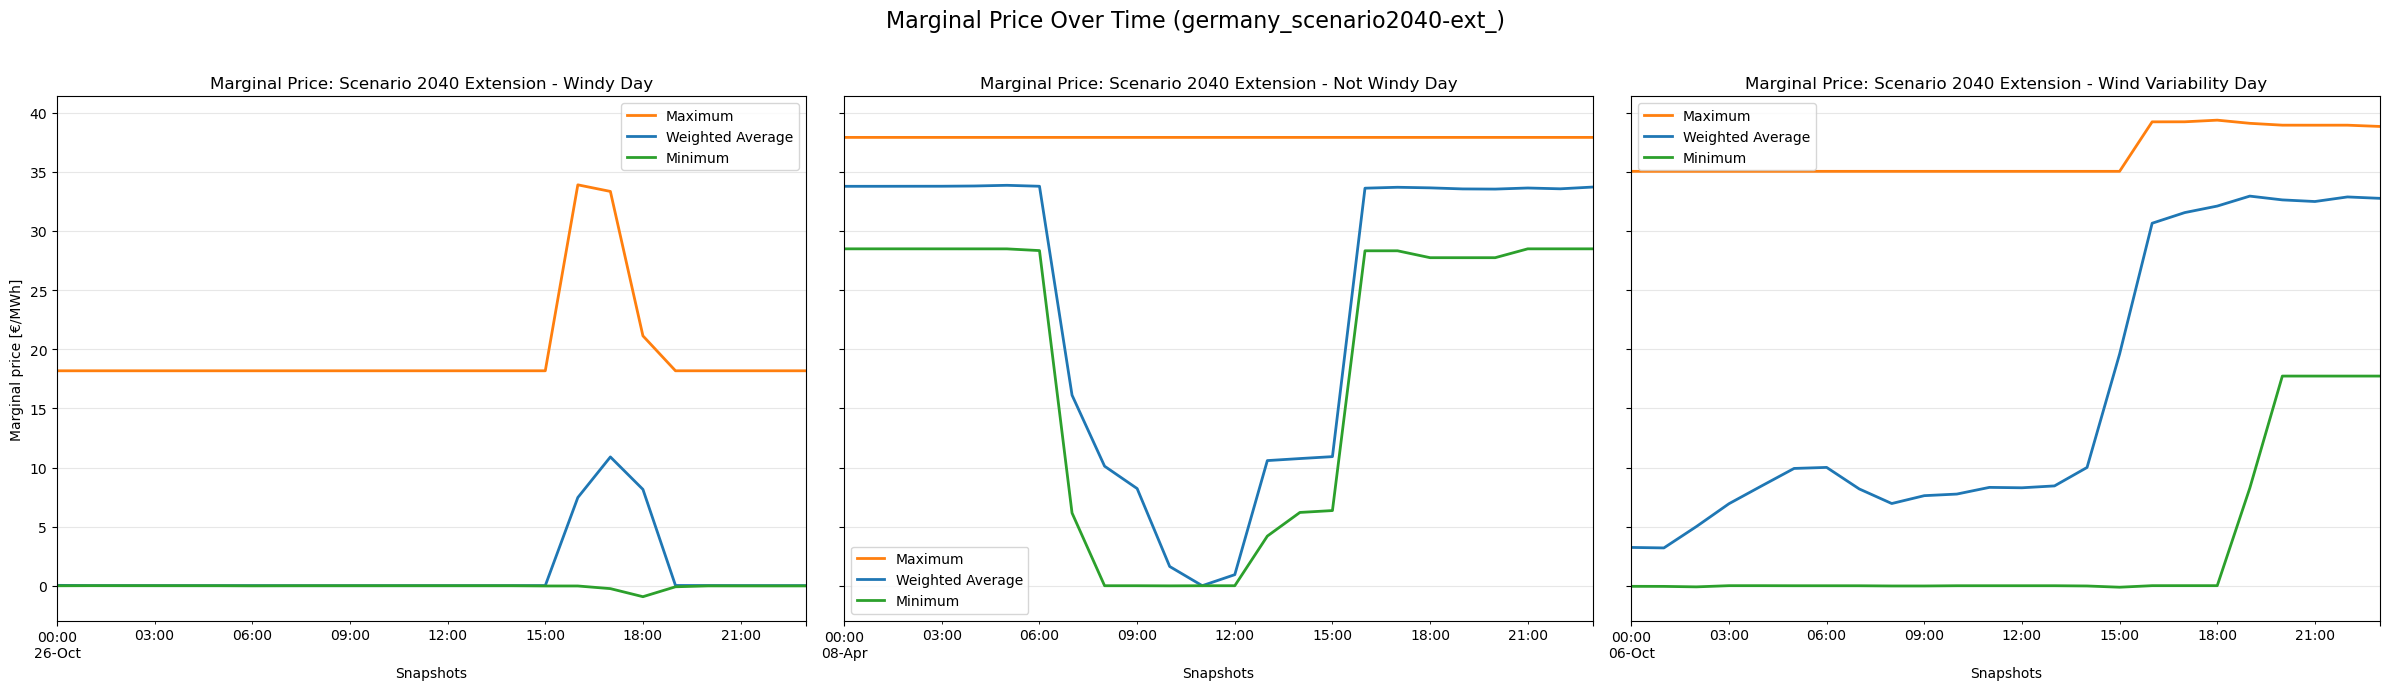

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)
fig.suptitle(f"Marginal Price Over Time ({folder})", fontsize=16)

for ax, network in zip(axes, [n1, n2, n3]):
    if network.buses_t.marginal_price.empty:
        avg_marginal_price = pd.Series(0.0, index=network.snapshots)
        min_marginal_price = pd.Series(0.0, index=network.snapshots)
        max_marginal_price = pd.Series(0.0, index=network.snapshots)
        log_print(f"No marginal price data found for {network.name}.")
    else:
        # Calculate load-weighted average marginal price
        prices = network.buses_t.marginal_price
        # Aggregate loads per bus
        bus_loads = network.loads_t.p_set.T.groupby(network.loads.bus).sum().T
        # Ensure bus_loads has the same columns as prices, filling missing with 0
        bus_loads = bus_loads.reindex(columns=prices.columns, fill_value=0.0)
        
        total_load = bus_loads.sum(axis=1)
        # Avoid division by zero for snapshots with no load
        weighted_avg_price = (prices * bus_loads).sum(axis=1) / total_load.where(total_load != 0, 1)
        
        avg_marginal_price = weighted_avg_price
        min_marginal_price = network.buses_t.marginal_price.min(axis=1)
        max_marginal_price = network.buses_t.marginal_price.max(axis=1)
    
    max_marginal_price.plot(ax=ax, color="tab:orange", lw=2)
    avg_marginal_price.plot(ax=ax, color="tab:blue", lw=2)
    min_marginal_price.plot(ax=ax, color="tab:green", lw=2)
   
    ax.set_title(f"Marginal Price: {network.name} Day" )
    ax.set_xlabel("Snapshots")
    ax.set_ylabel("Marginal price [€/MWh]")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(["Maximum", "Weighted Average", "Minimum"])

    log_print("=" * 70)
    log_print(f"Network: {network.name}")
    log_print(avg_marginal_price.describe().to_string())
    log_print("=" * 70)
    log_print("")

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "average_marginal_prices.png")

### Load Shedding
Unserved load is identified from generators whose carrier contains load, summed by bus, and plotted at the snapshot with the highest total shedding. Bus sizes and colors show the shed power, while line loading uses |p0| / s_nom.

 Network: Scenario 2040 Extension - Windy
  Average loading across all lines: 23.38%
  Max average loading: 289.87%
  Lines with >60% avg loading: 26
  Lines with >70% avg loading: 11

 Network: Scenario 2040 Extension - Not Windy
  Average loading across all lines: 25.54%
  Max average loading: 111.38%
  Lines with >60% avg loading: 44
  Lines with >70% avg loading: 32

 Network: Scenario 2040 Extension - Wind Variability
  Average loading across all lines: 64.42%
  Max average loading: 426.63%
  Lines with >60% avg loading: 250
  Lines with >70% avg loading: 211

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/load_shedding.png


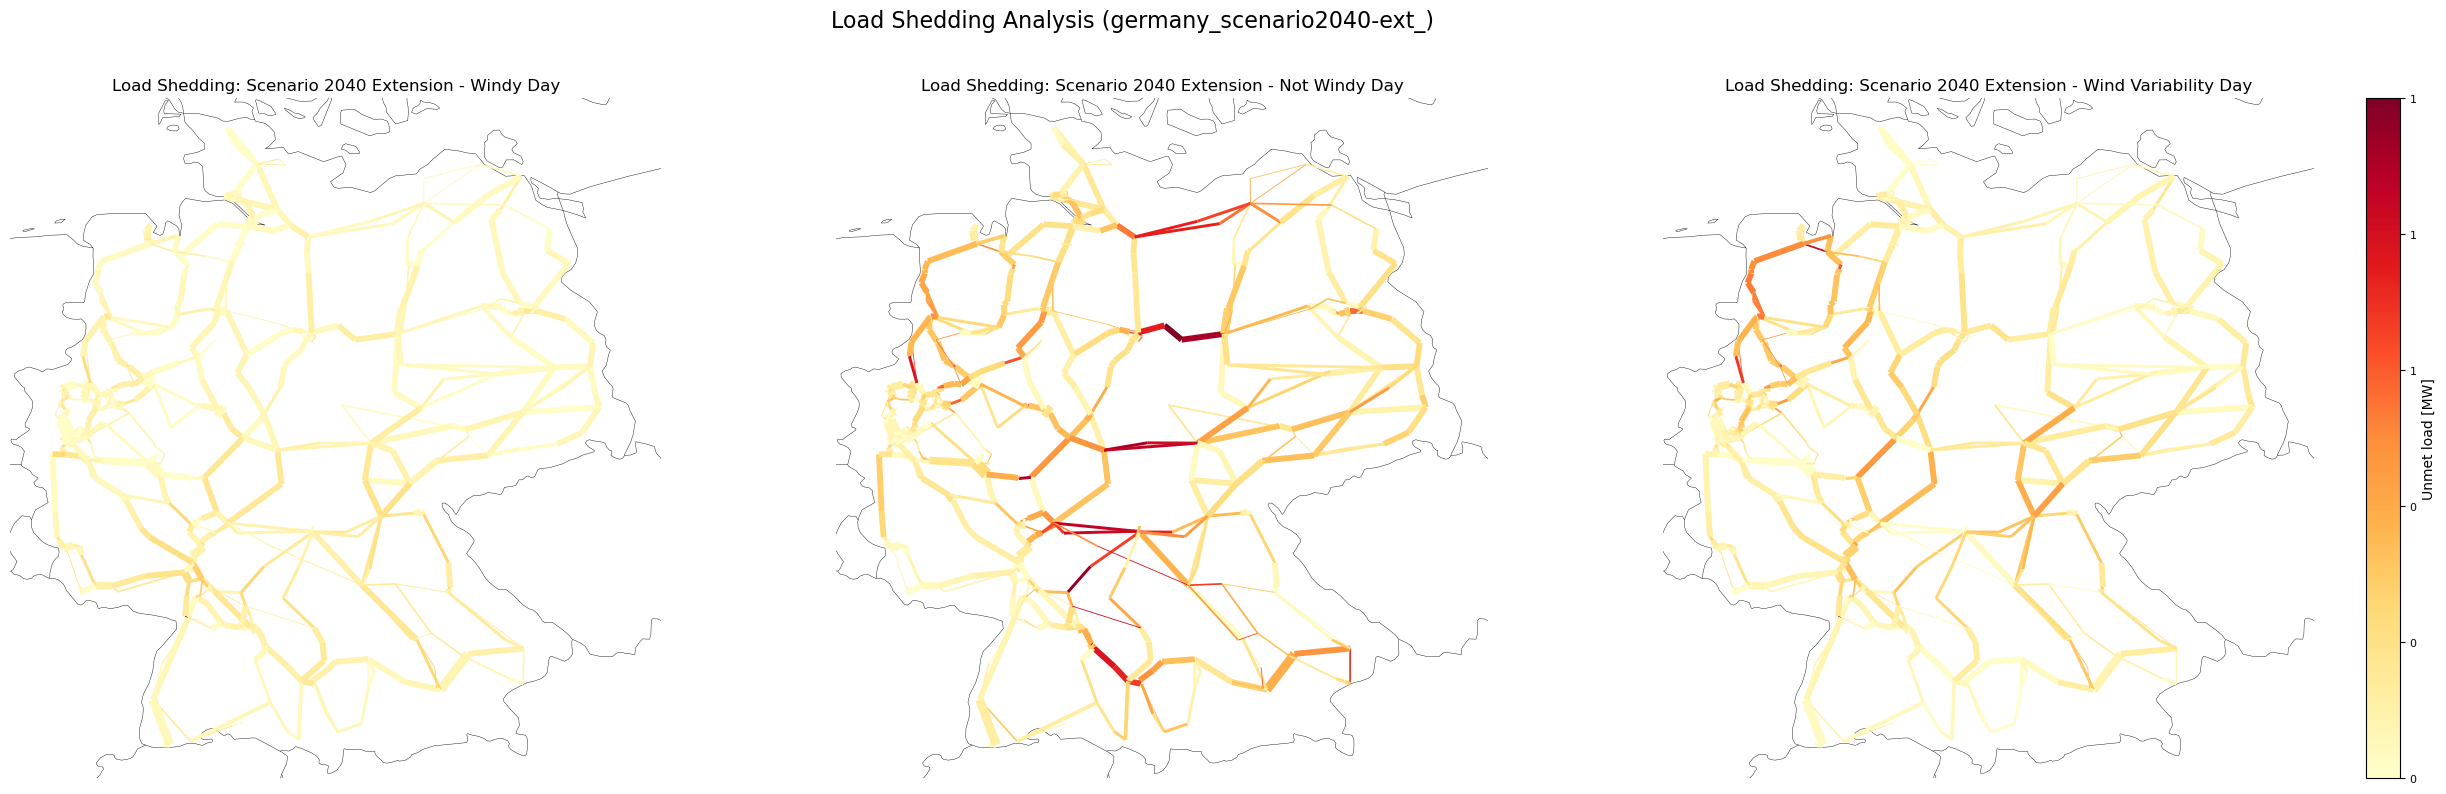

In [ ]:
# --- Create enhanced visualization ---
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Load Shedding Analysis ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Average Loading ---
# Collect unmet-load maxima to build a shared colorbar across subplots
unmet_max_list = []

def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        log_print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"]).sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]

    # Track the maximum unmet load for this network for a shared colorbar later
    unmet_max_list.append(unmet_load_at_snapshot.max())

    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=unmet_load_at_snapshot/2000,
        bus_alpha=0.7,
        bus_colors=unmet_load_at_snapshot,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 800,
        link_width=n.links.p_nom / 800 if not n.links.empty else 0,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], "Load Shedding: " + n.name + " Day")
    log_print("=" * 70)
    log_print(f" Network: {n.name}")
    log_print(f"  Average loading across all lines: {avg_loading.mean():.2%}")
    log_print(f"  Max average loading: {avg_loading.max():.2%}")
    log_print(f"  Lines with >60% avg loading: {(avg_loading > 0.6).sum()}")
    log_print(f"  Lines with >70% avg loading: {(avg_loading > 0.7).sum()}")
    log_print("=" * 70)
    log_print("")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])

# Create a shared colorbar for bus colors (unmet load) using the same colormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
max_unmet = max(unmet_max_list) if unmet_max_list else 1.0
# Ensure a non-zero vmax to avoid division-by-zero in Normalize
vmax_unmet = max(max_unmet, 1.0)
bus_mappable = ScalarMappable(norm=Normalize(vmin=0.0, vmax=vmax_unmet), cmap=plt.get_cmap("YlOrRd"))
bus_mappable.set_array([])

cbar_unmet = fig.colorbar(bus_mappable, ax=list(axes), orientation="vertical", fraction=0.02, pad=0.02)
# Choose readable ticks with slightly more resolution at low values
ticks = np.unique(np.concatenate(([0.0], np.linspace(0.0, vmax_unmet, num=6))))
cbar_unmet.set_ticks(ticks)
cbar_unmet.set_ticklabels([f"{t:.0f}" for t in ticks])
cbar_unmet.ax.tick_params(labelsize=8)
cbar_unmet.set_label('Unmet load [MW]')

save_fig(fig, "load_shedding.png")

In [ ]:
n.links.groupby("carrier").sum()

,bus0,bus1,type,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,p_nom_extendable,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,reversed
carrier,,,,,,,,,,,,,,,,,,,,,
H2 Electrolysis,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,,314.730000,450,0,11250.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.095124,0
H2 Fuel Cell,DE0 0 H2DE0 1 H2DE0 10 H2DE0 100 H2DE0 101 H2D...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,225.000000,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,0.066275,0
battery charger,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,27284.165884,0
battery discharger,DE0 0 batteryDE0 1 batteryDE0 10 batteryDE0 10...,DE0 0DE0 1DE0 10DE0 100DE0 101DE0 102DE0 103DE...,,440.908154,450,0,4500.0,0.0,0.0,450,...,0,0,450,0,0.0,0.0,0.0,0.0,27846.785197,0


#### Offshore Wind Curtailment
Available power is calculated as p_max_pu times p_nom, dispatched power comes from generators_t.p, and curtailment is the positive difference between them. This figure compares those quantities for offwind-ac generators across the three networks.


#### Parameter Documentation for New Curtailment Function

**Parameters Used:**

1. **`generators.p_nom`** (static, MW) — Installed/nameplate capacity
   - *Why:* Represents the fixed maximum power the generator can produce (unless extendable).
   - *Used when:* Generator capacity was not optimized.

2. **`generators.p_nom_opt`** (output, MW) — Optimized capacity after solving
   - *Why:* After optimization, if `p_nom_extendable=True`, this holds the actual capacity built. For post-solve analysis, we should use this.
   - *Fallback:* If `p_nom_opt` is NaN, we fall back to `p_nom`.
   - **This is the key fix:** The old function ignored optimization, always using `p_nom`.

3. **`generators_t.p_max_pu`** (time series, per unit, 0-1) — Maximum output availability factor
   - *Why:* For renewables, this is the capacity factor from weather (wind speed, solar irradiance). For conventional plants, it's the de-rating factor (maintenance, forced outages, etc.).
   - *Formula:* Available Power[t] = `p_max_pu[t]` × `p_nom_eff`

4. **`generators_t.p`** (time series, MW) — Actual dispatched power (solver output)
   - *Why:* This is what was actually generated. Curtailment = Available − Dispatched.

5. **`generators.carrier`** (string) — Energy carrier type (e.g., 'onwind', 'offwind-ac', 'solar')
   - *Why:* Allows filtering/grouping by technology type for separate analysis.

**The Curtailment Equation:**

$$\text{Curtailed Power}[t] = \max\left(0, \, p\_max\_pu[t] \times p\_nom\_eff \, - \, p[t] \right)$$

where $p\_nom\_eff = p\_nom\_opt$ if extendable (and not NaN), otherwise $p\_nom$.


In [ ]:
def plot_curtailment(n, carrier, ax):
    # Time-series available / dispatched / curtailed aggregated by carrier
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = (p_available_by_carrier - p_by_carrier).clip(lower=0)

    # Use friendly display name for the title, but keep the legend generic.
    carrier_display = carrier_label(carrier)
    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    # Build a dataframe for plotting while keeping the legend labels generic.
    p_df = pd.DataFrame(
        {
            "dispatched": p_by_carrier[carrier],
            "curtailed": p_curtailed_by_carrier[carrier],
            "available": p_available_by_carrier[carrier],
        }
    )
    p_df["capacity"] = capacity

    # Plot stacked dispatched + curtailed area, then available and capacity lines
    p_df[["dispatched", "curtailed"]].plot(kind="area", ax=ax, lw=0, legend=False)
    p_df[["available", "capacity"]].plot(ax=ax, legend=False)

    # Compute totals for logging
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()

    # Axis formatting and explicit generic legend handles.
    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df["capacity"].max() * 1.1 if hasattr(p_df["capacity"], "max") else None])
    ax.set_title(f"{carrier_display} Curtailment: {n.name} Day")

    legend_handles = [
        Patch(facecolor="tab:blue", edgecolor="none", label="dispatched"),
        Patch(facecolor="tab:orange", edgecolor="none", label="curtailed"),
        Line2D([0], [0], color="tab:green", lw=2, label="available"),
        Line2D([0], [0], color="tab:red", lw=2, label="capacity"),
    ]
    ax.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, -0.12), frameon=False)

    # Log summary using display-name
    log_print("=" * 70)
    log_print(f"Network: {n.name}")
    log_print(f"{carrier_display} capacity MW: {n.generators.groupby('carrier')['p_nom'].sum().get(carrier):.2f}")
    log_print(f"Total available (MWh): {tot_av:.2f}")
    log_print(f"Total dispatched (MWh): {tot_disp:.2f}")
    log_print(f"Total curtailed (MWh): {tot_cur:.2f}")
    log_print(f"Curtailed fraction: {tot_cur / tot_av if tot_av else float('nan'):.2f}")
    log_print("=" * 70)
    log_print("")

#### offwind

Network: Scenario 2040 Extension - Windy
Offshore wind (AC) capacity MW: 66000.00
Total available (MWh): 1396516.72
Total dispatched (MWh): 52583.30
Total curtailed (MWh): 1343933.41
Curtailed fraction: 0.96

Network: Scenario 2040 Extension - Not Windy
Offshore wind (AC) capacity MW: 66000.00
Total available (MWh): 49167.88
Total dispatched (MWh): 49153.87
Total curtailed (MWh): 14.01
Curtailed fraction: 0.00

Network: Scenario 2040 Extension - Wind Variability
Offshore wind (AC) capacity MW: 66000.00
Total available (MWh): 1026137.76
Total dispatched (MWh): 370412.35
Total curtailed (MWh): 655725.41
Curtailed fraction: 0.64

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/offwind_curtailment.png


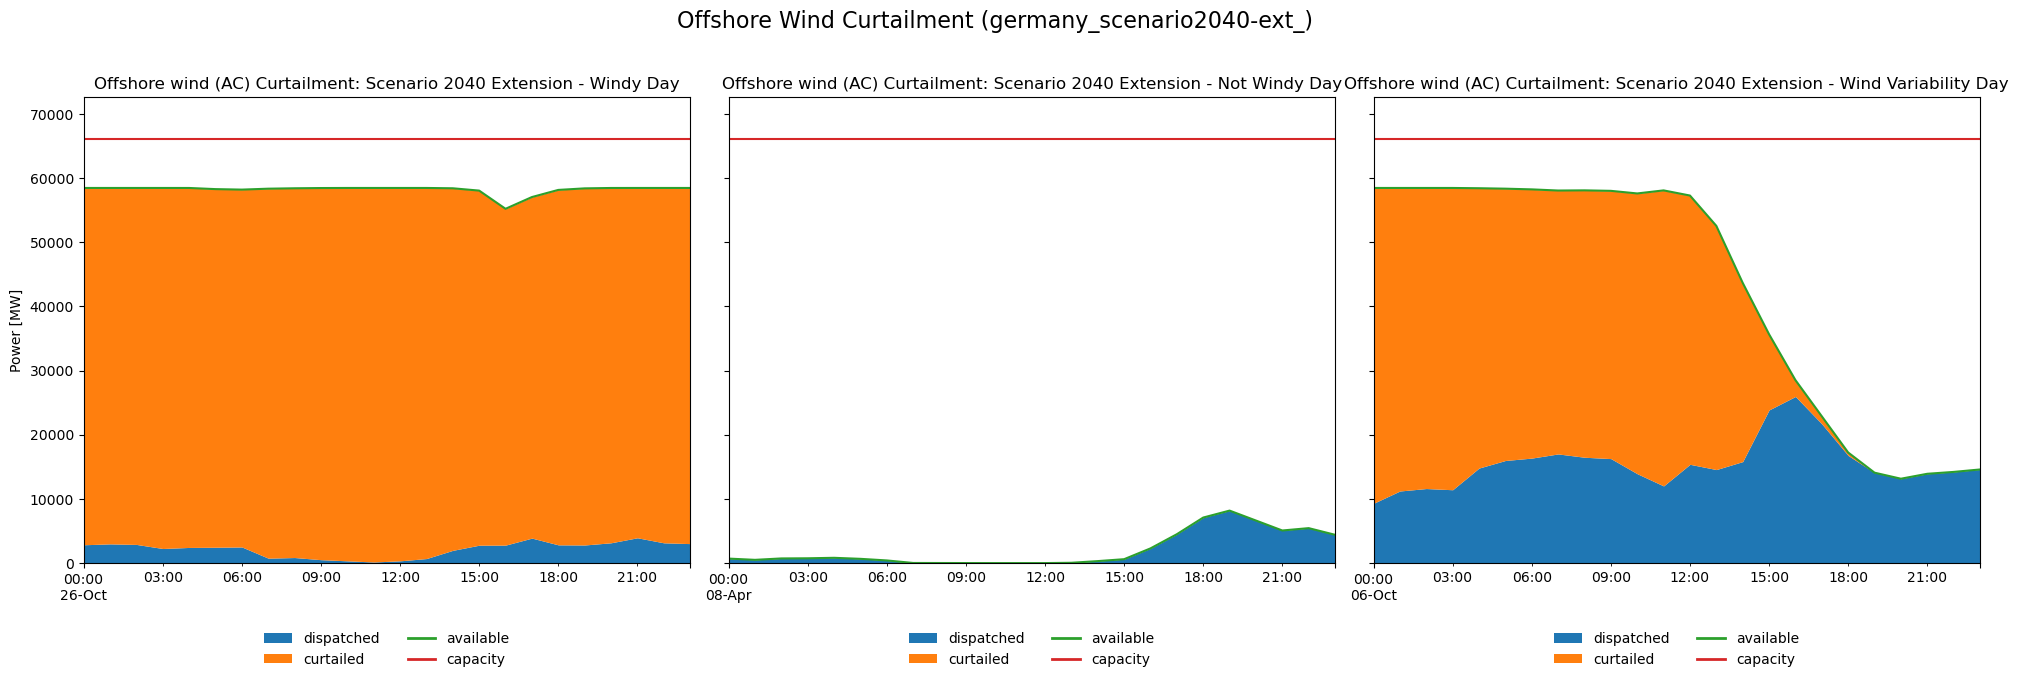

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle(f"Offshore Wind Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "offwind_curtailment.png")

#### Onshore Wind Curtailment
Available power is calculated as p_max_pu times p_nom, dispatched power comes from generators_t.p, and curtailment is the positive difference between them. This figure compares those quantities for onwind generators across the three networks.

Network: Scenario 2040 Extension - Windy
Onshore wind capacity MW: 209000.00
Total available (MWh): 4334287.09
Total dispatched (MWh): 1348408.21
Total curtailed (MWh): 2985878.88
Curtailed fraction: 0.69

Network: Scenario 2040 Extension - Not Windy
Onshore wind capacity MW: 209000.00
Total available (MWh): 140893.32
Total dispatched (MWh): 138413.44
Total curtailed (MWh): 2479.88
Curtailed fraction: 0.02

Network: Scenario 2040 Extension - Wind Variability
Onshore wind capacity MW: 209000.00
Total available (MWh): 2293807.42
Total dispatched (MWh): 1567279.23
Total curtailed (MWh): 726528.19
Curtailed fraction: 0.32

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/onwind_curtailment.png


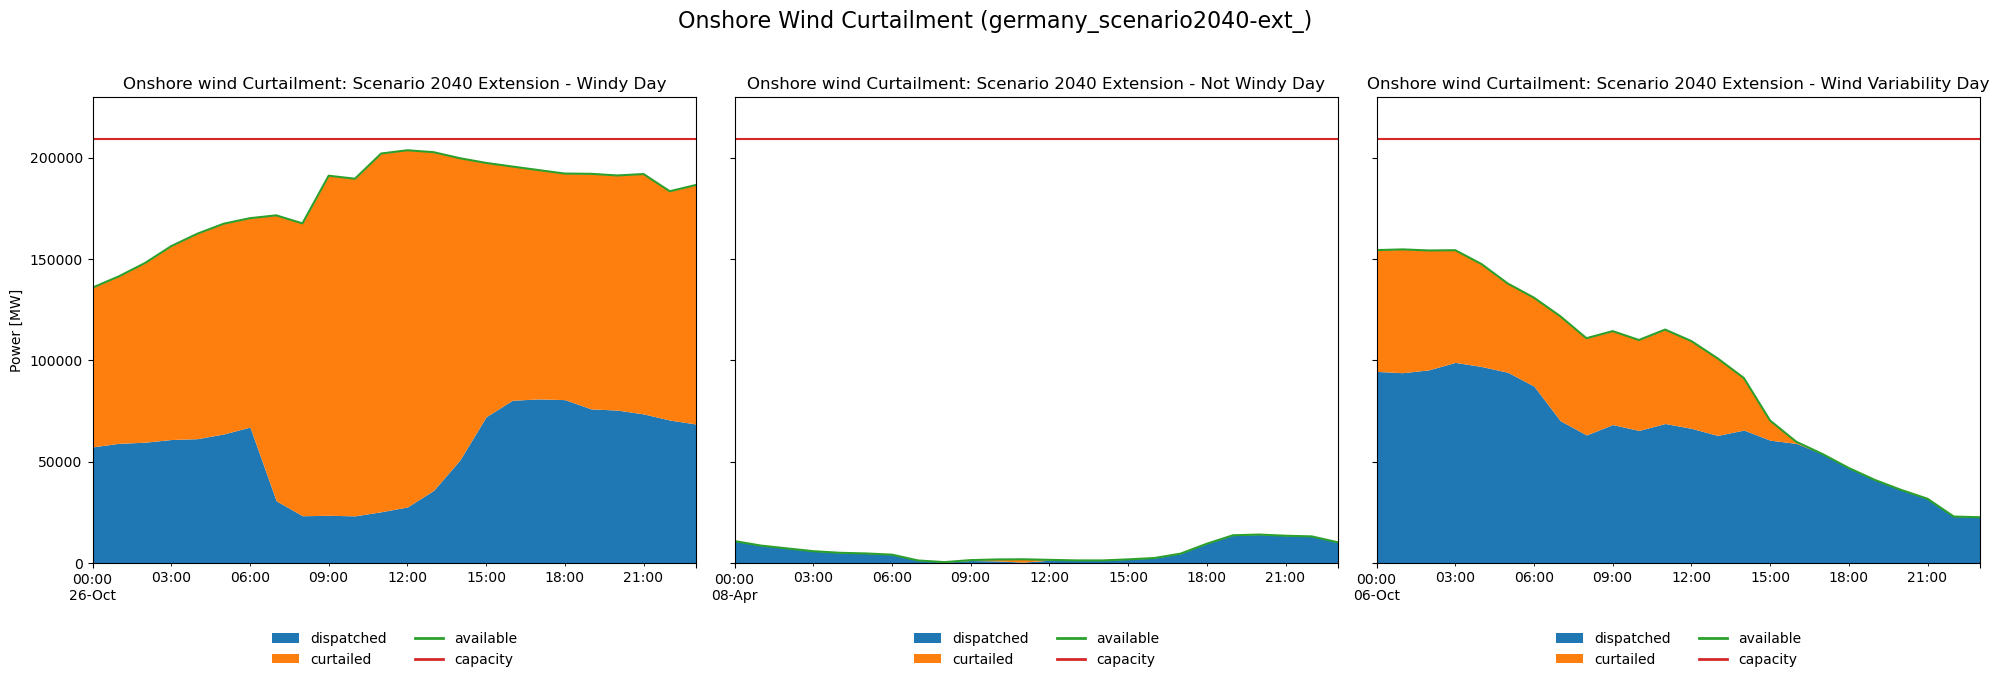

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle(f"Onshore Wind Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "onwind_curtailment.png")

#### Solar Curtailment
Available power is p_max_pu times p_nom, dispatched power is generators_t.p, and curtailed power is the positive difference between them. This figure compares those quantities for solar generators across the three networks.

Network: Scenario 2040 Extension - Windy
Solar PV capacity MW: 367000.00
Total available (MWh): 517236.41
Total dispatched (MWh): 437885.31
Total curtailed (MWh): 79351.10
Curtailed fraction: 0.15

Network: Scenario 2040 Extension - Not Windy
Solar PV capacity MW: 367000.00
Total available (MWh): 1861083.32
Total dispatched (MWh): 1774313.11
Total curtailed (MWh): 86770.21
Curtailed fraction: 0.05

Network: Scenario 2040 Extension - Wind Variability
Solar PV capacity MW: 367000.00
Total available (MWh): 382771.37
Total dispatched (MWh): 378092.15
Total curtailed (MWh): 4679.22
Curtailed fraction: 0.01

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/solar_curtailment.png


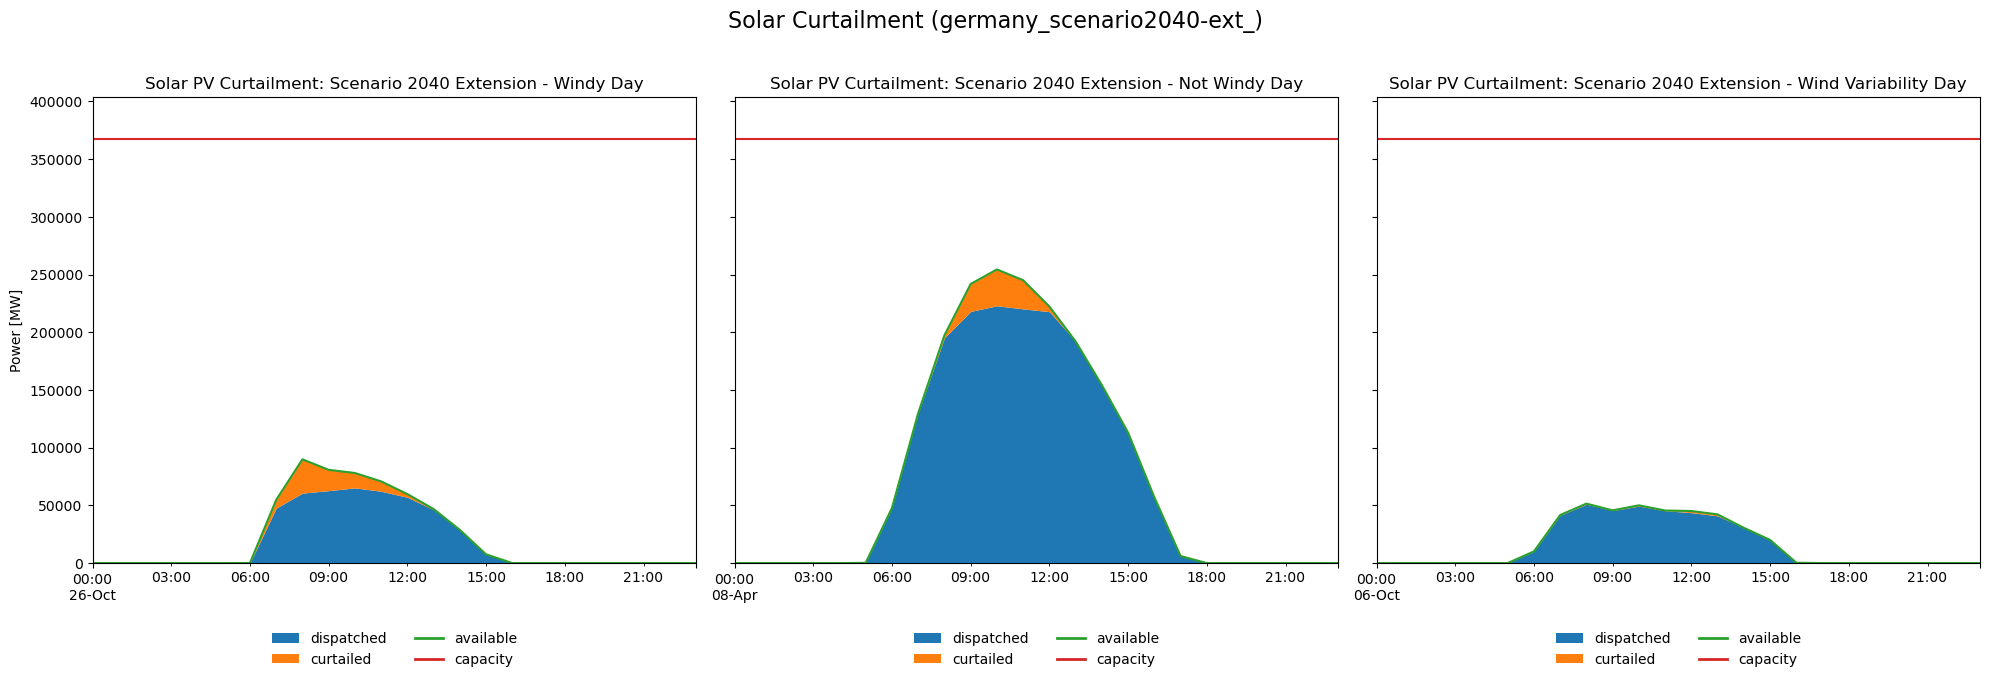

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.suptitle(f"Solar Curtailment ({folder})", fontsize=16)

plot_curtailment(n1, "solar", axes[0])
plot_curtailment(n2, "solar", axes[1])
plot_curtailment(n3, "solar", axes[2])

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "solar_curtailment.png")

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier
Generation is summed by carrier from generators_t.p, battery discharge is added from battery discharger links, and demand is the total load from loads_t.p_set. The stacked areas show the supply mix against demand.

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/power_dispatch.png


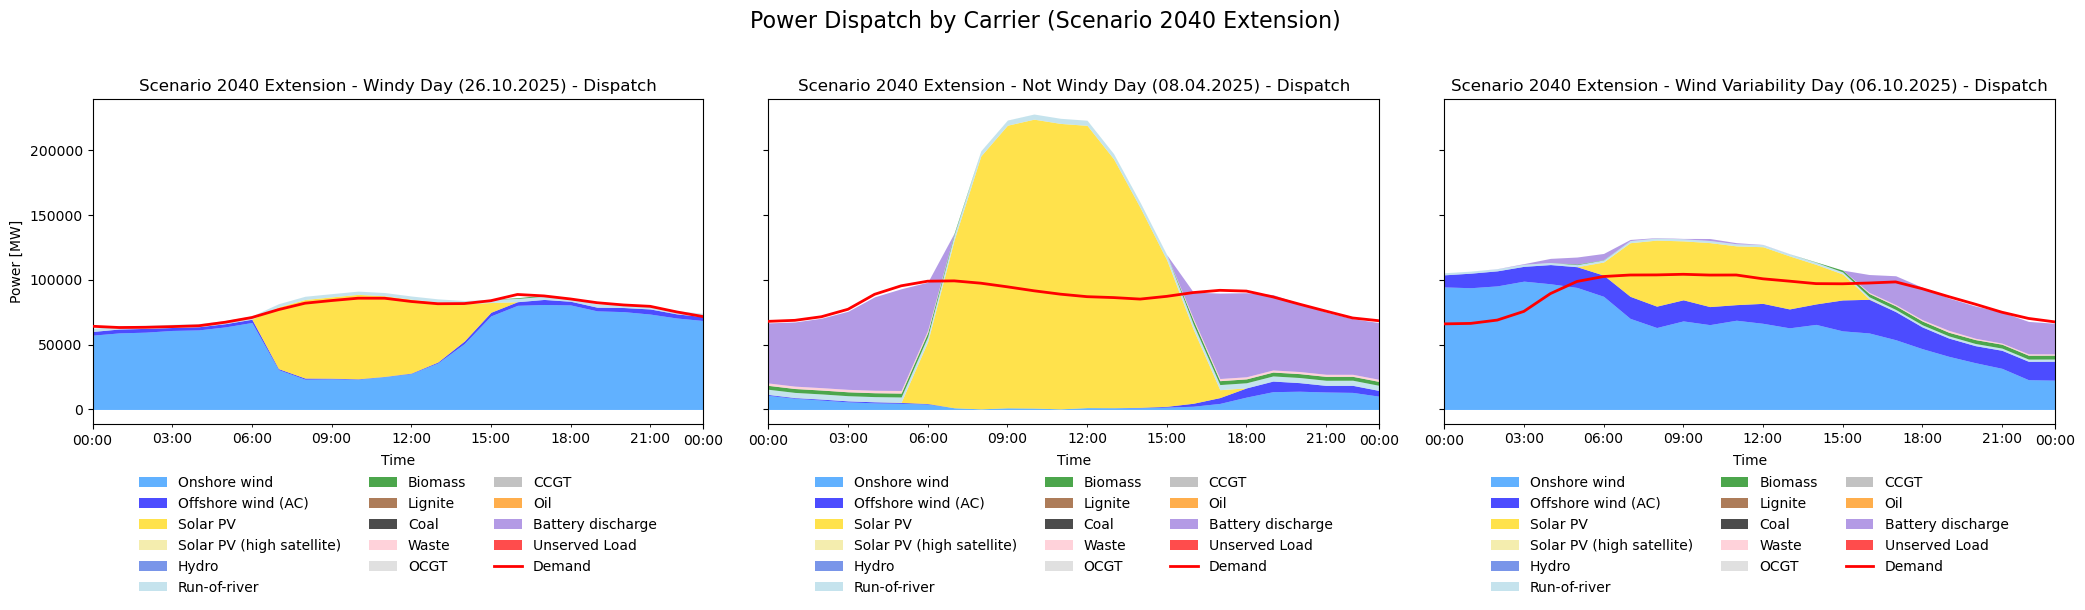

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=figure_formatting["figsize"], sharey=figure_formatting["sharey"])
fig.suptitle(f"Power Dispatch by Carrier ({scenario_display_name})", fontsize=16)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "blue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "lightblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    #"geothermal": "firebrick",
    "battery discharge": "mediumpurple",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", #"geothermal",
    # Conventional
    "lignite", "coal", "waste",
    "OCGT", "CCGT", "oil",
    # Storage
    "battery discharge",
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]
    p_by_carrier.columns = [carrier_label(col) for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, color=c, alpha=figure_formatting["area_alpha"])

    # Add demand curve using shared line formatting
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(
        ax=ax,
        color=figure_formatting["grid_line_color"],
        lw=figure_formatting["grid_line_width"],
        label="Demand",
        zorder=figure_formatting["grid_line_zorder"],
    )

    # Keep readable network names while still mapping to the correct actual data file.
    if "Not Windy" in n.name:
        scenario_data_key = "not_windy"
    elif "Wind Variability" in n.name:
        scenario_data_key = "wind_variability"
    else:
        scenario_data_key = "windy"

    real_data = pd.read_csv(
        f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_data_key}.csv",
        index_col=0,
        parse_dates=True,
    )
    real_data.index = pd.to_datetime(real_data.index)
    # Align to the network snapshots so missing hours do not break the plot
    demand_real = real_data["grid load"].reindex(n.snapshots)
    demand_real.name = "Actual Demand"
    # Shift real data by two hours
    if scenario_data_key == "windy":
        demand_real = demand_real.shift(-1)
    else:
        demand_real = demand_real.shift(-2)
    #demand_real.plot(ax=ax, color="red", linestyle="--", lw=2, label="Actual Demand")

    apply_standard_timeseries_format(ax, title, n.snapshots[0].strftime("%d.%m.%Y"), title_suffix="Dispatch")
    ax.legend(
        ncol=figure_formatting["legend_ncol"],
        loc=figure_formatting["legend_loc"],
        bbox_to_anchor=figure_formatting["legend_bbox_to_anchor"],
        frameon=figure_formatting["legend_frameon"],
    )


# --- Plotting ---
plot_dispatch(n1, axes[0], n1.name)
plot_dispatch(n2, axes[1], n2.name)
plot_dispatch(n3, axes[2], n3.name)

fig.tight_layout(rect=[0, figure_formatting["bottom_margin"], 1, 0.96])
save_fig(fig, "power_dispatch.png")

In [ ]:
##### Wind-Only Power Dispatch
This is the same carrier-summed dispatch calculation as above, but limited to onwind and offshore wind carriers. It highlights how much of the supply in each scenario comes from wind.

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/power_dispatch_wind-only.png


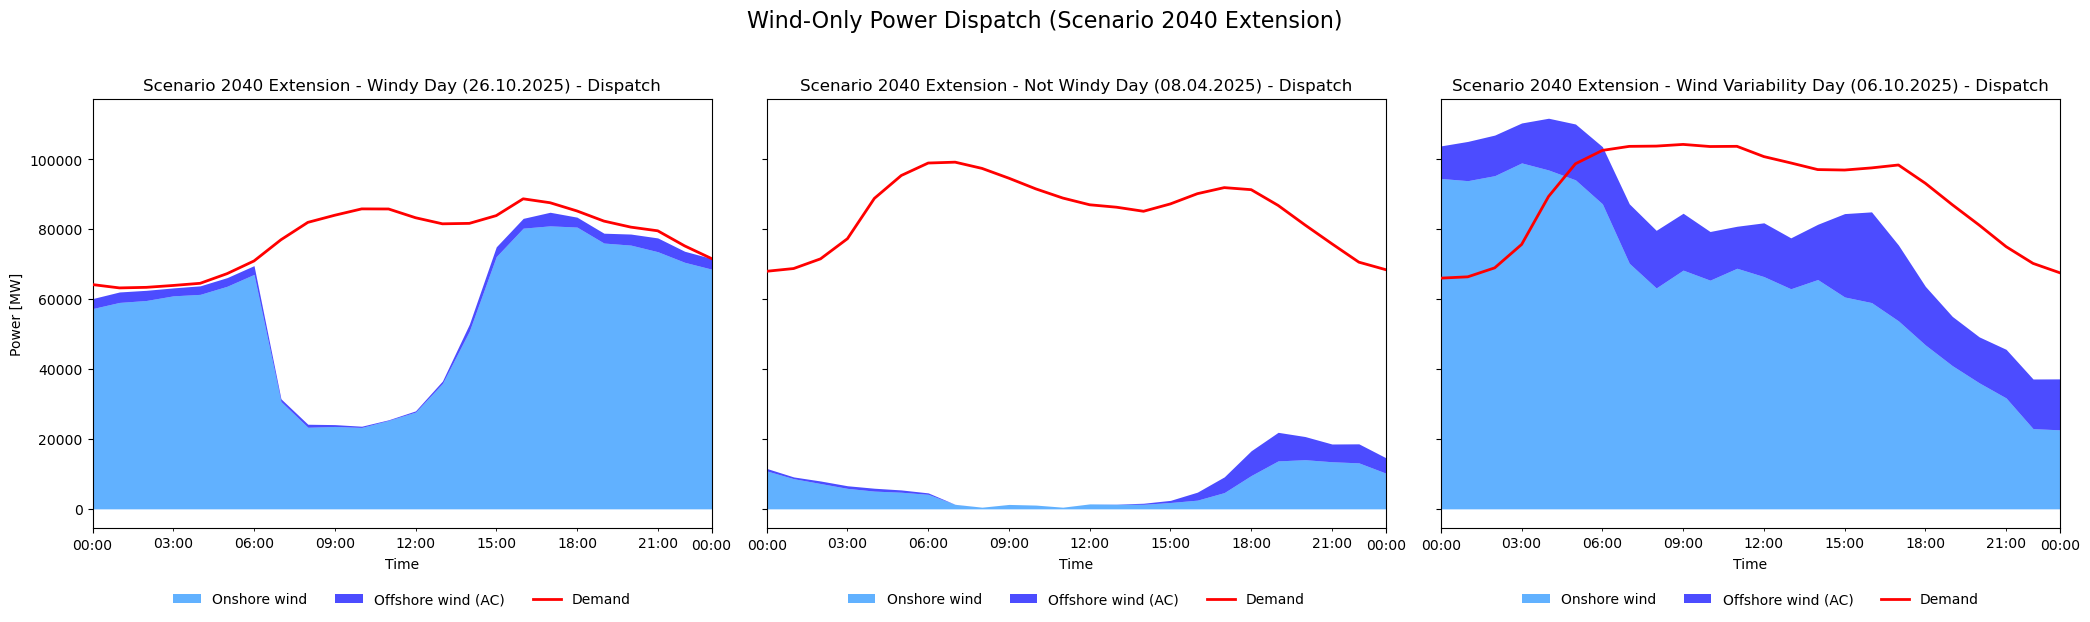

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=figure_formatting["figsize"], sharey=figure_formatting["sharey"])
fig.suptitle(f"Wind-Only Power Dispatch ({scenario_display_name})", fontsize=16)

cols = [
    # Renewables
    "onwind", "offwind-ac", 
]

# --- Plotting ---
plot_dispatch(n1, axes[0], n1.name)
plot_dispatch(n2, axes[1], n2.name)
plot_dispatch(n3, axes[2], n3.name)

fig.tight_layout(rect=[0, figure_formatting["bottom_margin"], 1, 0.96])
save_fig(fig, "power_dispatch_wind-only.png")

In [ ]:
### Curtailment Analysis by Carrier
Curtailment is calculated as max(0, p_max_pu * p_nom_eff - p). Generators are grouped into solar, onshore wind, and offshore wind, then aggregated by bus so the map shows where curtailment is highest.

Plotting 'Scenario 2040 Extension - Windy' network at time 2025-10-26 11:00:00 with peak curtailment 243582.44 MW
Plotting 'Scenario 2040 Extension - Not Windy' network at time 2025-04-08 10:00:00 with peak curtailment 32211.51 MW
Plotting 'Scenario 2040 Extension - Wind Variability' network at time 2025-10-06 00:00:00 with peak curtailment 108983.62 MW
Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/curtailment_map_by_carrier_pie.png


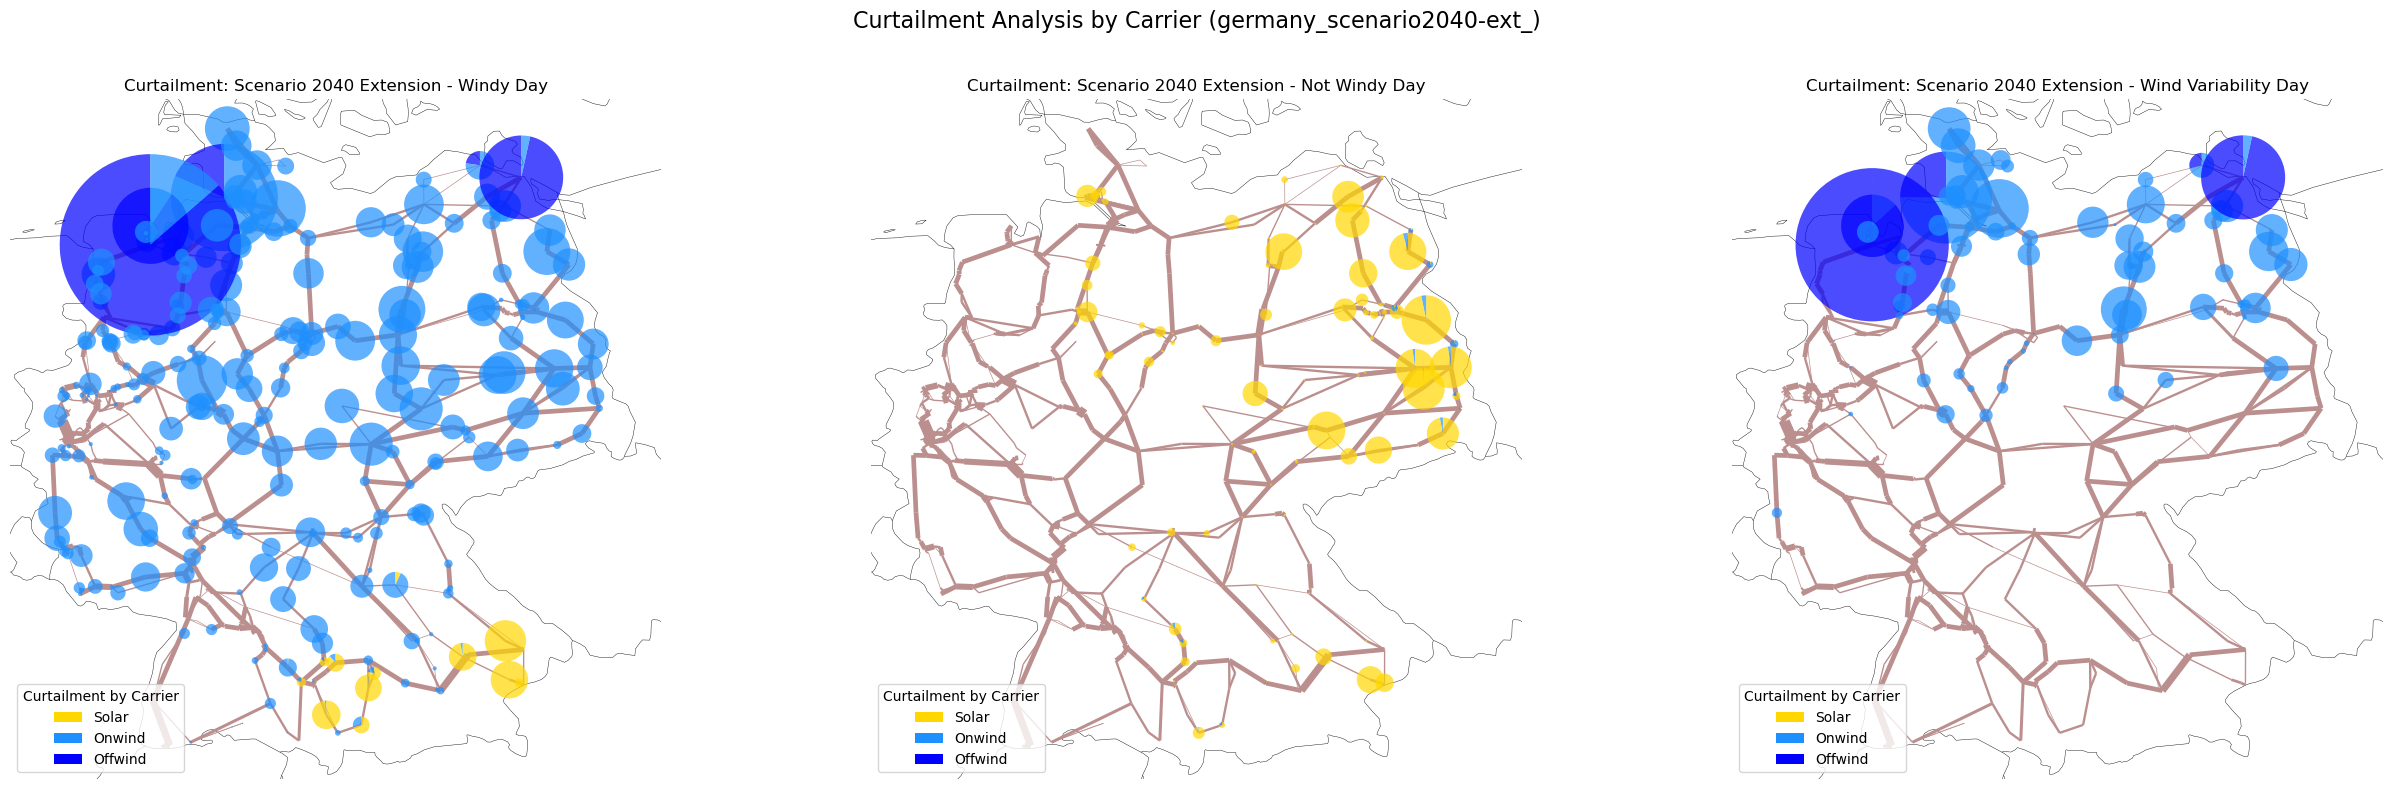

In [ ]:
# --- Create enhanced visualization for curtailment ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})
fig.suptitle(f"Curtailment Analysis by Carrier ({folder})", fontsize=16)

# --- Helper Function to Plot Network with Curtailment ---
def plot_network_curtailment(n, ax, title):
    # Effective capacity: p_nom_opt if available, otherwise p_nom
    p_nom_eff = n.generators.p_nom_opt.where(n.generators.p_nom_opt.notna(), n.generators.p_nom)
    
    # Time-series of available power
    p_available = n.generators_t.p_max_pu.multiply(p_nom_eff)
    
    # Time-series of dispatched power
    p_dispatched = n.generators_t.p
    
    # Time-series of curtailed power
    p_curtailed = (p_available - p_dispatched).clip(lower=0)

    # Define carrier groups
    carrier_groups = {
        'solar': ['solar', 'solar-hsat'],
        'onwind': ['onwind'],
        'offwind': ['offwind-ac', 'offwind-dc', 'offwind-float']
        #'conventional': ['lignite', 'coal', 'oil', 'OCGT', 'CCGT', 'biomass', 'waste', 'geothermal', 'hydro', 'ror']
    }
    
    # Invert carrier_groups to map from carrier to group name
    carrier_to_group = {carrier: group for group, carriers in carrier_groups.items() for carrier in carriers}
    
    # Map generator carriers to the defined groups
    gen_groups = n.generators.carrier.map(carrier_to_group).rename('group')

    # Aggregate curtailment by bus and by carrier group
    curtailment_by_bus_group_time = p_curtailed.T.groupby([n.generators.bus, gen_groups]).sum().T
    
    # Total curtailment for finding the worst snapshot
    total_curtailment_time = p_curtailed.sum(axis=1)
    worst_curtailment_snapshot = total_curtailment_time.idxmax()
    
    # Curtailment at the worst snapshot, aggregated by bus and group
    curtailment_snapshot = curtailment_by_bus_group_time.loc[worst_curtailment_snapshot]
    
    # Define colors for carrier groups
    group_colors = {
        'solar': 'gold',
        'onwind': 'dodgerblue',
        'offwind': 'blue'
        #'conventional': 'darkgray'
    }
    
    log_print(f"Plotting '{n.name}' network at time {worst_curtailment_snapshot} with peak curtailment {total_curtailment_time.max():.2f} MW")

    bus_size_factor = 30000

    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=curtailment_snapshot / bus_size_factor,
        bus_colors=group_colors,
        bus_alpha=0.7,
        #line_colors=(n.lines_t.p0.abs() / n.lines.s_nom).mean(),
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 1000,
        link_width=n.links.p_nom / 1000 if not n.links.empty else 0,
    )
    
    # Create a legend for the carrier groups
    legend_handles = [Patch(facecolor=color, label=group.capitalize()) for group, color in group_colors.items()]
    ax.legend(handles=legend_handles, loc='lower left', title='Curtailment by Carrier')


# Plot Curtailment for each network
i = 0
for n in networks.values():
    plot_network_curtailment(n, axes[i], "Curtailment: " + n.name + " Day")
    i += 1

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "curtailment_map_by_carrier_pie.png")

##### Total Energy Production by Carrier
Total generation is the sum of generators_t.p over the analysis window, grouped by carrier and converted from MWh to TWh. The stacked bars compare the three network cases.

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2040-ext_/total_energy_production.png

=== Energy Production Summary ===
                           Windy     Not Windy  Wind Variability
Onshore wind        1.348408e+06  1.384134e+05      1.567279e+06
Solar PV            4.378853e+05  1.774313e+06      3.780921e+05
Offshore wind (AC)  5.258330e+04  4.915387e+04      3.704123e+05
Run-of-river        5.985295e+04  9.540780e+04      3.916467e+04
Biomass             1.436865e+03  4.607674e+04      2.531203e+04
Waste               3.928253e-03  2.605030e+04      8.253453e+03
Geothermal          6.454502e+02  6.444192e+02      6.455919e+02
CCGT                4.602095e-03  1.251221e+00      3.831326e-01
OCGT                5.813298e-03  9.992697e-01      3.446515e-01




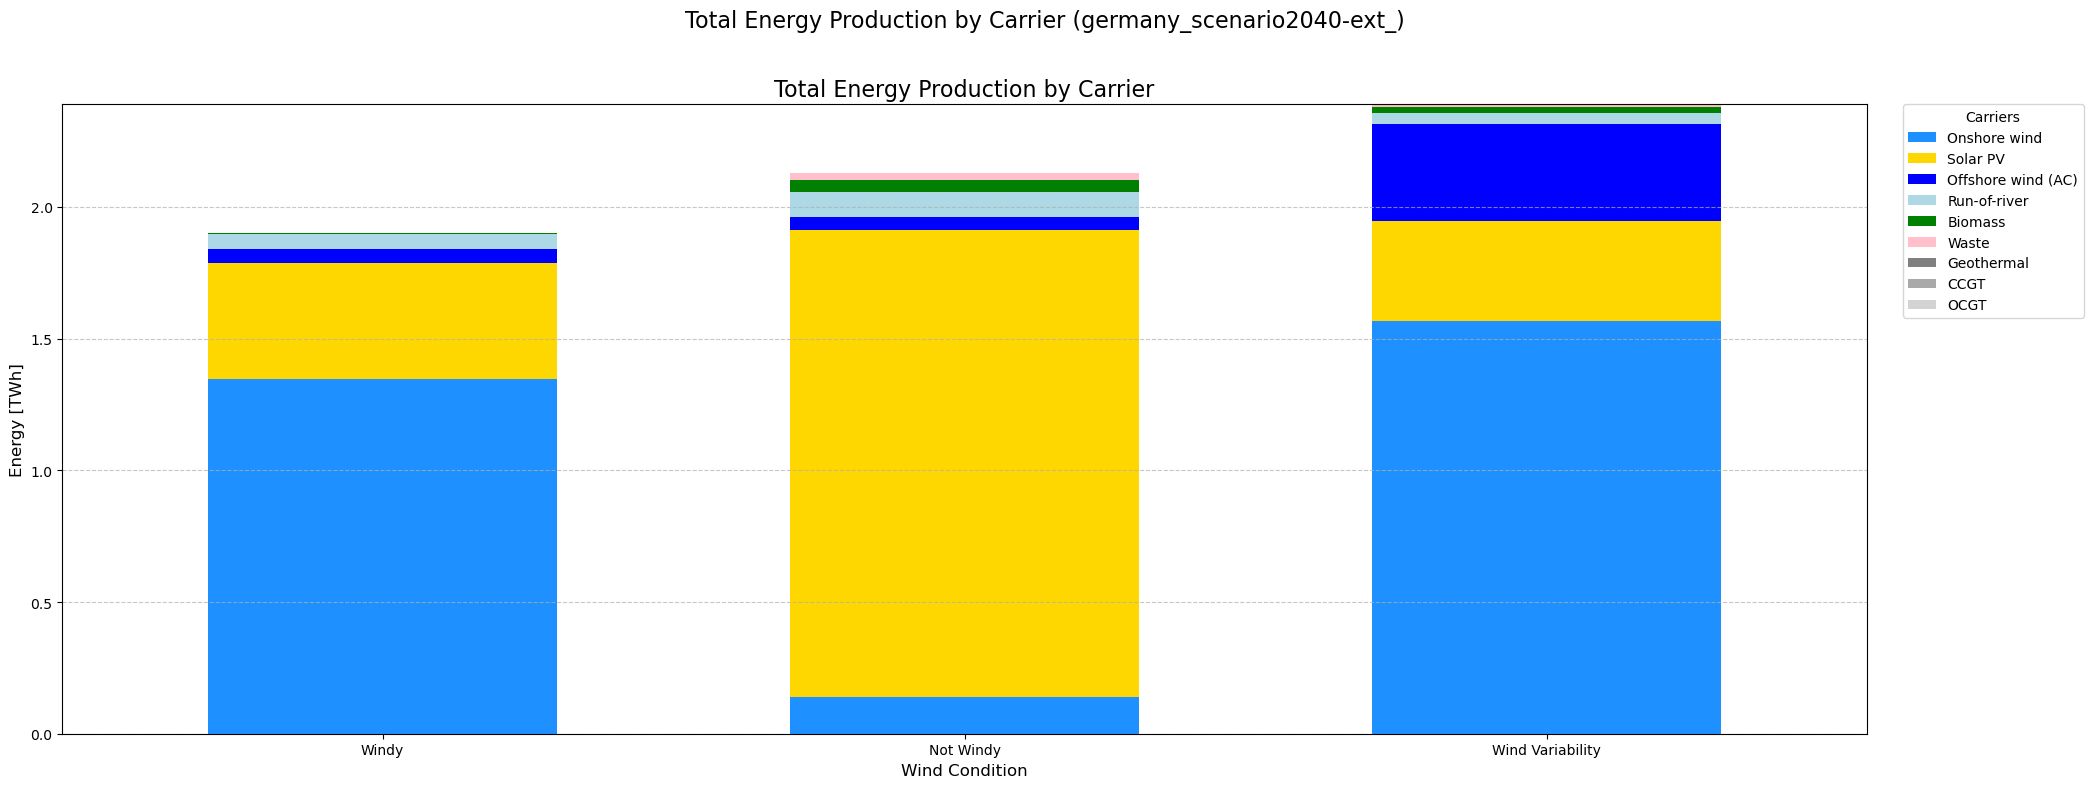

In [ ]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]
carrier_keys = list(energy_df.index)
energy_df.index = [carrier_label(carrier) for carrier in carrier_keys]

# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in carrier_keys]

# --- Plotting ---
fig, ax = plt.subplots(figsize=figure_formatting["figsize"])
fig.suptitle(f"Total Energy Production by Carrier ({folder})", fontsize=16)

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Wind Condition", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, "total_energy_production.png")

# Log energy production summary
log_print("\n=== Energy Production Summary ===")
log_print(energy_df.to_string())
log_print("\n")

In [ ]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

log_print("\n=== CO2 Emissions Summary ===")
for n in networks.values():
    log_print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")
log_print("\n")


=== CO2 Emissions Summary ===
Total CO2 emissions at the Scenario 2040 Extension - Windy day: 77.46 kg CO2
Total CO2 emissions at the Scenario 2040 Extension - Not Windy day: 24552.92 kg CO2
Total CO2 emissions at the Scenario 2040 Extension - Wind Variability day: 7638.46 kg CO2




### Statistics

In [ ]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    log_print(n.statistics().to_string())
    log_print("\n")

log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")


=== Network Statistics ===

Network: Scenario 2040 Extension - Windy
                                  Optimal Capacity  Installed Capacity        Supply    Withdrawal  Energy Balance  Transmission  Capacity Factor   Curtailment  Capital Expenditure  Operational Expenditure       Revenue  Market Value
Generator   Combined-Cycle Gas        2.900000e+04        2.900000e+04  4.600000e-03  0.000000e+00    4.600000e-03        0.0000     6.551724e-09  6.960000e+05         1.004525e+07                  0.21524  7.960000e-03      1.736842
            Offshore Wind (AC)        6.600000e+04        6.600000e+04  5.258330e+04  0.000000e+00    5.258330e+04        0.0000     3.319653e-02  1.343933e+06         5.386255e+07               1264.40084  1.264397e+03      0.024046
            Onshore Wind              2.090000e+05        2.090000e+05  1.348408e+06  0.000000e+00    1.348408e+06        0.0000     2.688214e-01  2.985879e+06         6.803659e+07              33188.91251  8.114209e+05      0.6

### Interactive Line Loading Maps
These maps use the average line loading |p0| / s_nom for each network, and the line width scales with s_nom. They provide a web view of the same congestion metric used in the static plot.

In [ ]:
for n in networks.values():

    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()

    map=n.explore(
        line_color=avg_loading_n,
        line_width= n.lines.s_nom / 500,
        line_cmap="YlOrRd",
        bus_alpha=0.2,
        line_alpha=0.5,
        bus_color = "lightblue",
    )

    path_to_dir = f"{analysis_dir}/interactive_map_{n.name}.html"
    map.to_html(path_to_dir)

### Base Network Preview
This is a minimal map of the selected network geometry with buses and branches hidden by setting sizes and widths to zero. It serves as a layout check for the chosen scenario.

{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x7c2443957390>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x7c2443957250>,
  'Line': <matplotlib.collections.LineCollection at 0x7c2443957110>},
 'flows': {}}

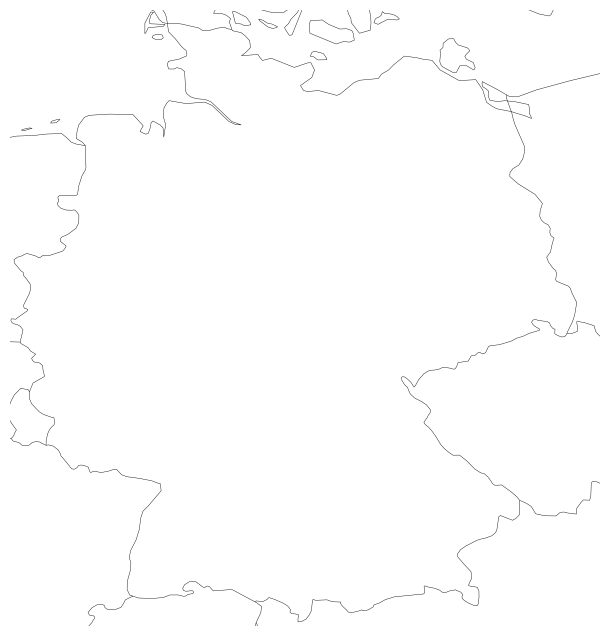

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth()})


n1.plot(
    ax=axes,
    geomap=True,
    bus_sizes=0,
    line_width=0,
    link_width=0,
)